# DESI PV Y1 $z$-bin TFR Calibration w/o zero-pointing

In redshift bins of width 0.001 (or 0.005), identify DESI observations with measurements suitable for the Tully-Fisher relation. Export the SGA IDs of the TFR galaxies and apply a multi-bin joint fit to calibrate the TFR at $0.4R_{26}$, weighting the galaxies in the fit by $V(z=0.2)/V_{max}$.  Only use those galaxies which HDBSCAN identifies as being part of the central population.

Version: **10 August 2025**

**Note:** This requires using a subclassed version of `hyperfit`.

In [51]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
from matplotlib import cm, colors
from matplotlib.patches import Ellipse
import matplotlib as mpl

# We have more than 10 redshift bins, so we need to change the default color map so that they are all plotted with different colors
# from cycler import cycler
# plt.rcParams['axes.prop_cycle'] = cycler('color', plt.get_cmap('tab20').colors)

import ligo.skymap.plot

from astropy.table import Table, vstack, join
from astropy.coordinates import SkyCoord, Distance
from astropy.cosmology import Planck18, FlatLambdaCDM
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import SphericalCircle
from astropy import units as u
from astropy import constants as c
from astropy import constants as const
from astropy.io import fits

from cosmoprimo.fiducial import DESI

from scipy.spatial.distance import cdist, euclidean

import os

from corner import corner, hist2d
import math
import pickle

from sklearn.covariance import EllipticEnvelope
from matplotlib.patches import Ellipse
from scipy.stats import chi2

from tqdm import tqdm
from hdbscan import HDBSCAN
from scipy.stats import binned_statistic
from matplotlib.projections import get_projection_names

from desiutil.plots import init_sky

# Custom functions / classes
import sys
# sys.path.insert(1, '/global/u1/k/kadglass/DESI_SGA/TF/')
# sys.path.insert(1, '/Users/kdouglass/Documents/Research/DESI/PV_survey/code/TF/')
sys.path.insert(1, '/global/u1/s/sgmoore1/DESI_SGA/TF/')
from help_functions import adjust_lightness
from line_fits import hyperfit_line_multi
from TF_photoCorrect import BASS_corr, MW_dust, k_corr, internal_dust
from z_CMB_convert import convert_z_frame

In [52]:
# Base values for later conversions (all in units in km/s).
c_kms = c.c.to_value('km/s')

h = 1.
H0 = 100*h

q0 = 0.2

# Access SGA Iron Data

The following selections have already been applied:
* `DELTACHI2 > 25` & `ZWARN = 0` for the centers
* $10 < V < 1000$ km/s and $\Delta V / V_\text{min}$ for the observations at $0.4R_{26}$
* Visual inspection

In [53]:
# sgapath = '/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y1'
sgapath = '../vrot_cats'
# sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot.fits')
sgafits = os.path.join(sgapath, 'SGA-2020_loa_Vrot_v3.fits')

sgatab = Table.read(sgafits)
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64
20,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.6411,0.6362121,0.53480667,2.8045392,1.7123051,17.22401,0.6144014,0.53440714,2.7180903,2.1161501,17.062769,0.44818503,0.43006793,3.1755726,0.97457016,0,0.08361393354574793,2.585694723746872e-05,N,136.40320332954073,12.846761926303119
32,SGA-2020 32,PGC2

## Compute maximum volume for each galaxy

Since the SGA is a size-limited catalog ($D_{26} > 0.2$ arcmin), there is a maximum volume within which each galaxy could be located to be included in the SGA.  Let's calculate that maximum volume so that we can use it as a weight in the TFR calibration.

In [54]:
Planck18_h = FlatLambdaCDM(H0=100, Om0=0.3151)

In [55]:
dist = Distance(z=np.abs(sgatab['Z_DESI']), cosmology=Planck18_h)

sgatab['D26_kpc'] = 2*dist.to('kpc')*np.tan(0.5*sgatab['D26']*u.arcmin)

sgatab['DIST_MAX'] = 0.5*sgatab['D26_kpc']/np.tan(0.1*u.arcmin)

dist_max = Distance(z=0.1, cosmology=Planck18_h)

sgatab['MAX_VOL_FRAC'] = sgatab['DIST_MAX'].to('Mpc')**3 / dist_max.to('Mpc')**3

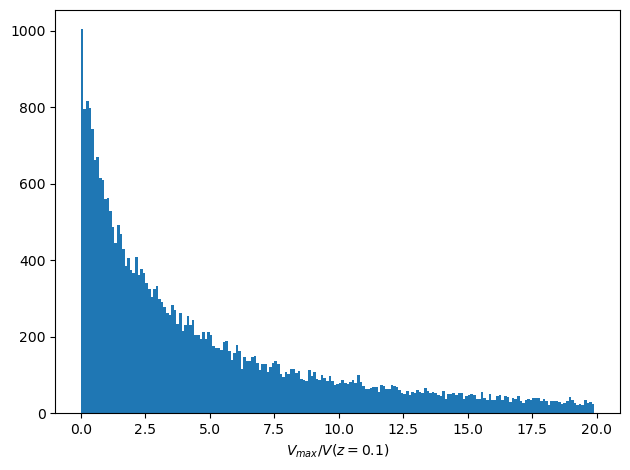

In [56]:
plt.figure(tight_layout=True)

plt.hist(sgatab['MAX_VOL_FRAC'], np.arange(0, 20, 0.1))

plt.xlabel('$V_{max}$/$V(z = 0.1)$');

## Convert to CMB frame

In [57]:
sgatab['Z_DESI_CMB'] = convert_z_frame(sgatab['Z_DESI'], sgatab['RA'], sgatab['DEC'])

# Load Morphological Classification

## SSL

As an alternative to morphological classification of the galaxies, we also produced a classification based on the SSL sorter (using a nearest-neighbor query; Largett et al., in prep.). The classification ignored the Hubble sub-types and grouped the galaxies into four main categories:
1. Spiral
2. Elliptical
3. Lenticular
4. Irregular

Let's also load this table and add it to the SGA table.

In [58]:
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv'
ai_morphpath = '.'
# ai_morphpath = '/global/cfs/cdirs/desi/science/td/pv/SGA2020'
# ai_morphcsv = os.path.join(ai_morphpath, 'sga10278_morphologies_model_analysis.csv')
ai_morphcsv = '/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/SGAY3TFMorphologies.csv'
ai_morphtab = Table.read(ai_morphcsv)
ai_morphtab

SGA_ID,Predicted_Type_spiral,Predicted_Type_elliptical,Predicted_Type_irregular,Predicted_Type_lenticular,Predicted_Type
float64,str6,str10,str9,str10,str10
218203.0,Other,Other,Irregular,Other,Irregular
218205.0,Other,Other,Irregular,Other,Irregular
218239.0,Other,Other,Irregular,Other,Irregular
218275.0,Other,Other,Irregular,Other,Irregular
218304.0,Spiral,Other,Other,Other,Spiral
218367.0,Other,Other,Irregular,Other,Irregular
218376.0,Spiral,Other,Other,Other,Spiral
218201.0,Other,Other,Irregular,Other,Irregular
218385.0,Spiral,Other,Other,Other,Spiral


### Combine ML morphtypes with SGA catalog

In [59]:
sgatab = join(sgatab, ai_morphtab['SGA_ID', 'Predicted_Type'], keys='SGA_ID', join_type='left')

# Rename Predicted_Type to MORPHTYPE_AI
sgatab['Predicted_Type'].name = 'MORPHTYPE_AI'

## John Lucey's VI results

https://astro.dur.ac.uk/~jrl/DESI_TF_Y1/index.html

We are only considering galaxies that he considers bad for TF (strong asymmetry, double galaxies, stellar contamination).

In [60]:
lucey_VIpath = '../VI_JohnLucey/'

rejects = lucey_VIpath + 'REJECTS.txt'

reject_tab = Table.read(rejects, format='ascii.commented_header')
reject_tab['VI'] = 'reject'
reject_tab

SGA_ID,DESI_NAME,RA,Dec,z_desi,BA,G_R,G_R_err,V_0p4R26,V_0p4R26_err,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,LOGDIST_AVG,LOGDIST_AVG_ERR,MAIN,VI
int64,str22,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,str6
692,DESIXJ12411157+1819512,190.298193,18.330884,0.0691,0.5,0.4903,0.0288,85,6,16.7987,0.1126,0.1983,0.0552,0,reject
2526,DESIXJ10124098+4543539,153.170765,45.731651,0.0241,0.3969,0.3677,0.0227,46,6,16.4224,0.1398,0.1804,0.0717,0,reject
2804,DESIXJ07581109+3420293,119.546191,34.341483,0.0198,0.2924,0.5585,0.035,121,5,14.3538,0.1607,-0.0479,0.0527,0,reject
3420,DESIXJ01135557+0034028,18.48153,0.567434,0.0418,0.761,0.3742,0.0169,82,22,16.5482,0.0542,0.0391,0.1185,0,reject
5964,DESIXJ16261820+4219580,246.57584,42.332773,0.0465,0.9154,0.3389,0.0122,41,23,16.543,0.0311,0.4811,0.2514,0,reject
6243,DESIXJ13403564+1214293,205.148492,12.241463,0.0927,0.6161,0.8506,0.0122,315,14,15.3396,0.0872,-0.1452,0.0505,0,reject
6493,DESIXJ12450567+1054032,191.273606,10.900881,0.0035,0.8997,0.6761,0.0011,213,23,13.575,0.0287,-0.8711,0.0609,0,reject
7553,DESIXJ09534429-0005255,148.434553,-0.090407,0.0836,0.7665,0.6715,0.0185,237,20,15.136,0.0574,0.0103,0.0557,0,reject
8007,DESIXJ03051303-0700487,46.304307,-7.013516,0.0284,0.427,0.4408,0.0256,25,10,16.5644,0.1281,0.5769,0.1991,0,reject


### Combine John's results with Y1 TF sample

In [61]:
sgatab = join(sgatab, reject_tab['SGA_ID', 'VI'], keys='SGA_ID', join_type='left')

# Rename VI column to JOHN_VI
sgatab['VI'].name = 'JOHN_VI'

In [62]:
sgatab[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT,Z_DESI,ZERR_DESI,PHOTSYS,V_0p4R26,V_0p4R26_ERR,D26_kpc,DIST_MAX,MAX_VOL_FRAC,Z_DESI_CMB,MORPHTYPE_AI,JOHN_VI
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,kpc,kpc,,,,
float64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,float64,float64,bytes1,float64,float64,float64,float64,float64,float64,str10,str6
20.0,SGA-2020 20,SDSSJ173412.71+572041.6,3331584,263.5529355,57.34490699999999,S?,152.58,0.4487454,0.5333349,0.08364453,24.92448,18.036,False,LEDA-20181114,5,SDSSJ173412.71+572041.6,1,True,263.5529355,57.34490699999999,0.4487454,2635p572,263.55294849855886,57.344862145664294,0.4460123,SB26,152.3756,0.5778338,263.5528114673963,57.34481025685253,10.459747,5.9780583,5.751067,4.821581,1.4858595,3.4448266,5.1149526,6.748707,8.426254,9.720271,11.022999,12.0887985,13.380368,20.656942,20.044735,19.40886,19.194794,18.66572,18.231262,18.599888,18.123905,17.745926,18.256256,17.807074,17.476473,18.040592,17.60353,17.319197,17.926336,17.500519,17.228865,17.85259,17.42695,17.180876,17.811844,17.39206,17.151228,17.783718,17.36542,17.143204,0.02069058,0.026094317,0.03480586,0.05076174,0.08751116,0.10309491,0.08337893,0.10982923,0.13734566,0.031223593,0.046367057,0.0777883,0.015935475,0.020728666,0.032657374,0.012760426,0.014699919,0.022893604,0.010505663,0.011998588,0.018923525,0.010358521,0.011374098,0.017719442,0.010557283,0.0112259,0.017149422,0.010553381,0.011049819,0.017135512,0.010413324,0.010993488,0.01699026,0.010291049,0.010862263,0.017057167,17.641

# Photometric corrections

### Survey offsets

In [63]:
sys_corr, sys_corr_err = BASS_corr(sgatab['PHOTSYS'])

### MW dust corrections

In [64]:
# Import E(B-V) dust map
ebv_directory = '/global/cfs/cdirs/desicollab/users/rongpu/dust/desi_ebv/public_data/maps/'
# ebv_directory = '/Users/kdouglass/Documents/Research/data/DESI/'
ebv_filename = 'desi_dust_gr_512.fits'
ebv_map = Table.read(ebv_directory + ebv_filename)

In [65]:
MWdust_corr, MWdust_corr_err = MW_dust(sgatab['RA'], sgatab['DEC'], ebv_map)

/global/u1/s/sgmoore1/DESI_SGA/TF/TF_photoCorrect.py:90: UserWarning: Warning: converting a masked element to nan.
  EBV_err[i] = ebv_map['EBV_GR_ERR'][i_ebv]


In [66]:
# Flip NaN values to 0
MWdust_corr_err[np.isnan(MWdust_corr_err)] = 0

### $K$-corrections

In [67]:
# # Apparently we have some galaxies with negative redshifts
# zg0 = sgatab['Z_DESI'] >= 0

In [68]:
# kcorr_zg0 = k_corr(sgatab['Z_DESI'][zg0], 
#                    [sgatab['G_MAG_SB26'][zg0], sgatab['R_MAG_SB26'][zg0], sgatab['Z_MAG_SB26'][zg0]], 
#                    [sgatab['G_MAG_SB26_ERR'][zg0], sgatab['R_MAG_SB26_ERR'][zg0], sgatab['Z_MAG_SB26_ERR'][zg0]], 
#                    z_corr=0.1) # K-correcting to same redshift as FastSpecFit (which is what Caitlin's using for the FP)

In [69]:
# kcorr = np.zeros([len(sgatab), 3])
# kcorr[zg0] = kcorr_zg0

### Internal dust extinction correction

This is based off of a linear fit to ($b/a$, $m_r$), removing any correlation between $b/a$ and $m_r$.

In [70]:
# temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_z0p1_mcmc.pickle', 'rb')
temp_infile = open('/pscratch/sd/s/sgmoore1/TF/pickles/loa_internalDust_nokcorr_mcmc.pickle', 'rb')
# temp_infile = open('../loa_internalDust_nokcorr_mcmc.pickle', 'rb') #without k-corr
dust_mcmc_samples_r,_, dust_mcmc_samples_g,_, dust_mcmc_samples_z,_ = pickle.load(temp_infile)
temp_infile.close()

In [71]:
internalDust_coeffs_r = np.median(dust_mcmc_samples_r, axis=1)
internalDust_coeffs_g = np.median(dust_mcmc_samples_g, axis=1)
internalDust_coeffs_z = np.median(dust_mcmc_samples_z, axis=1)

internalDust_coeffs_err_r = np.zeros(len(internalDust_coeffs_r))
internalDust_coeffs_err_g = np.zeros(len(internalDust_coeffs_g))
internalDust_coeffs_err_z = np.zeros(len(internalDust_coeffs_z))

internalDust_coeffs_err_r[0] = np.std(dust_mcmc_samples_r[0][(-1.5 < dust_mcmc_samples_r[0]) & (dust_mcmc_samples_r[0] < 0)])
internalDust_coeffs_err_r[1] = np.std(dust_mcmc_samples_r[1][(0 < dust_mcmc_samples_r[1]) & (dust_mcmc_samples_r[1] < 1)])

internalDust_coeffs_err_g[0] = np.std(dust_mcmc_samples_g[0][(-1.5 < dust_mcmc_samples_g[0]) & (dust_mcmc_samples_g[0] < 0)])
internalDust_coeffs_err_g[1] = np.std(dust_mcmc_samples_g[1][(0 < dust_mcmc_samples_g[1]) & (dust_mcmc_samples_g[1] < 1)])

internalDust_coeffs_err_z[0] = np.std(dust_mcmc_samples_z[0][(-1.5 < dust_mcmc_samples_z[0]) & (dust_mcmc_samples_z[0] < 0)])
internalDust_coeffs_err_z[1] = np.std(dust_mcmc_samples_z[1][(0 < dust_mcmc_samples_z[1]) & (dust_mcmc_samples_z[1] < 1)])

In [72]:
internalDust_corr_r, internalDust_corr_err_r = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_r, 
                                                             internalDust_coeffs_err_r)

internalDust_corr_g, internalDust_corr_err_g = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_g, 
                                                             internalDust_coeffs_err_g)

internalDust_corr_z, internalDust_corr_err_z = internal_dust(sgatab['BA'], 
                                                             internalDust_coeffs_z, 
                                                             internalDust_coeffs_err_z)

## Apply corrections

In [73]:
# sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - kcorr[:,0] - internalDust_corr_g
# sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - kcorr[:,1] - internalDust_corr_r
# sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - kcorr[:,2] - internalDust_corr_z

In [74]:
##### without k-correction

sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26'] - MWdust_corr[0] + sys_corr - internalDust_corr_g
sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26'] - MWdust_corr[1] + sys_corr - internalDust_corr_r
sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26'] - MWdust_corr[2] + sys_corr - internalDust_corr_z

In [75]:
# #### no corrections
# sgatab['G_MAG_SB26_CORR'] = sgatab['G_MAG_SB26']
# sgatab['R_MAG_SB26_CORR'] = sgatab['R_MAG_SB26']
# sgatab['Z_MAG_SB26_CORR'] = sgatab['Z_MAG_SB26']

# sgatab['G_MAG_SB26_ERR_CORR'] = sgatab['G_MAG_SB26_ERR']
# sgatab['R_MAG_SB26_ERR_CORR'] = sgatab['R_MAG_SB26_ERR']
# sgatab['Z_MAG_SB26_ERR_CORR'] = sgatab['Z_MAG_SB26_ERR']

In [76]:
sgatab['G_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['G_MAG_SB26_ERR']**2 + MWdust_corr_err[0]**2 + sys_corr_err**2 + internalDust_corr_err_g**2)
sgatab['R_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['R_MAG_SB26_ERR']**2 + MWdust_corr_err[1]**2 + sys_corr_err**2 + internalDust_corr_err_r**2)
sgatab['Z_MAG_SB26_ERR_CORR'] = np.sqrt(sgatab['Z_MAG_SB26_ERR']**2 + MWdust_corr_err[2]**2 + sys_corr_err**2 + internalDust_corr_err_z**2)

# Redshift bins

Separate the galaxies into redshift bins of width 0.005, starting at a redshift of 0, so that we can fit an ellipse in each redshift bin.

In [77]:
zmin=0
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [78]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.000    4 galaxies
 1  0.000 < z <= 0.005  222 galaxies
 2  0.005 < z <= 0.010  612 galaxies
 3  0.010 < z <= 0.015  883 galaxies
 4  0.015 < z <= 0.020  1352 galaxies
 5  0.020 < z <= 0.025  1931 galaxies
 6  0.025 < z <= 0.030  2479 galaxies
 7  0.030 < z <= 0.035  2930 galaxies
 8  0.035 < z <= 0.040  2628 galaxies
 9  0.040 < z <= 0.045  2468 galaxies
10  0.045 < z <= 0.050  2144 galaxies
11  0.050 < z <= 0.055  2136 galaxies
12  0.055 < z <= 0.060  1971 galaxies
13  0.060 < z <= 0.065  1995 galaxies
14  0.065 < z <= 0.070  1898 galaxies
15  0.070 < z <= 0.075  1572 galaxies
16  0.075 < z <= 0.080  1517 galaxies
17  0.080 < z <= 0.085  1429 galaxies
18  0.085 < z <= 0.090  1060 galaxies
19  0.090 < z <= 0.095  761 galaxies
20  0.095 < z <= 0.100  625 galaxies
21  z > 0.100  3049 galaxies


# Apply Cuts Suitable for Calibrating the TFR

Requirements:
* $10~\mathrm{km/s} < V_\mathrm{rot} < 1000~\mathrm{km/s}$ at $0.4R_{26}$
* $\Delta V/V_\mathrm{min} \leq 5$
* Passed visual inspection (both ours and John Lucey's)
* $i > 45^\circ$
* Spiral-type morphology
* Not an outlier (based on fitting an ellipse to the data)

The first 2.5 items have already been applied (our VI results have already been applied, but not John's).

In [79]:
def fit_ellipse(x,y, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)
    return ee.location_, ee.covariance_

def plot_ellipse(mean, cov, ax, n_std=2.0, **kwargs):
    """
    Draw a confidence ellipse from mean and covariance.
    n_std=2 ~ 95% for 2D
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))

    width, height = 2 * n_std * np.sqrt(eigvals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        **kwargs
    )
    ax.add_patch(ellipse)

def ellipse_boolean(x,y,n_std, contam=0.05):
    X = np.vstack([x, y]).T
    ee = EllipticEnvelope(contamination=contam, random_state=0)
    ee.fit(X)

    mahal_sq = ee.mahalanobis(X)
    outlier_boolean = mahal_sq > n_std**2
    return outlier_boolean

## Fit an ellipse in each redshift bin

In [80]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [81]:
zmin=0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)
binwidth=dz

In [82]:
# sigma = 2.5
sigma = 2.86
mu_x = []
mu_y = []
cov_xx = []
cov_xy = []
cov_yx = []
cov_yy = []
z_min = []
# # fit the lowest bin in absolute magnitude space (if we don't want to start at zero)
# z_min.append(zmin)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 


for i in range(1,len(zbins)):
    z_min.append(0.005*(i-1))
    x = np.log10(sgatab['V_0p4R26'][zbin_indices==i])
    y = sgatab['R_MAG_SB26_CORR'][zbin_indices==i]

    ellipse_mean, ellipse_cov = fit_ellipse(x,y, contam=0.05)
    # print(ellipse_mean, ellipse_cov)
    mu_x.append(ellipse_mean[0])
    mu_y.append(ellipse_mean[1])
    cov_xx.append(ellipse_cov[0][0]) 
    cov_xy.append(ellipse_cov[0][1]) 
    cov_yx.append(ellipse_cov[1][0]) 
    cov_yy.append(ellipse_cov[1][1]) 

# # ## fit the highest bin in absolute magnitude space (if we care about above z=0.1)
# i=len(zbins)
# z_min.append(zmax)
# x = np.log10(sgatab['V_0p4R26'][zbin_indices==0])
# y = sgatab['R_ABSMAG_SB26'][zbin_indices==0]
# ellipse_mean, ellipse_cov = fit_ellipse(x,y)
# # print(ellipse_mean, ellipse_cov)
# mu_x.append(ellipse_mean[0])
# mu_y.append(ellipse_mean[1])
# cov_xx.append(ellipse_cov[0][0]) 
# cov_xy.append(ellipse_cov[0][1]) 
# cov_yx.append(ellipse_cov[1][0]) 
# cov_yy.append(ellipse_cov[1][1]) 

In [83]:
ellipse_params = Table([z_min, mu_x, mu_y, cov_xx, cov_xy, cov_yx, cov_yy],
    names=['zmin','MU_X', 'MU_Y', 'COV_XX', 'COV_XY', 'COV_YX', 'COV_YY'])
# ellipse_params.write(f'/global/homes/s/sgmoore1/DESI_SGA/TF/Y3/v2/TF_Y3_v7_ellipse_fit_mr_scale={sigma}_dz=0.005_params-lowcal.fits')

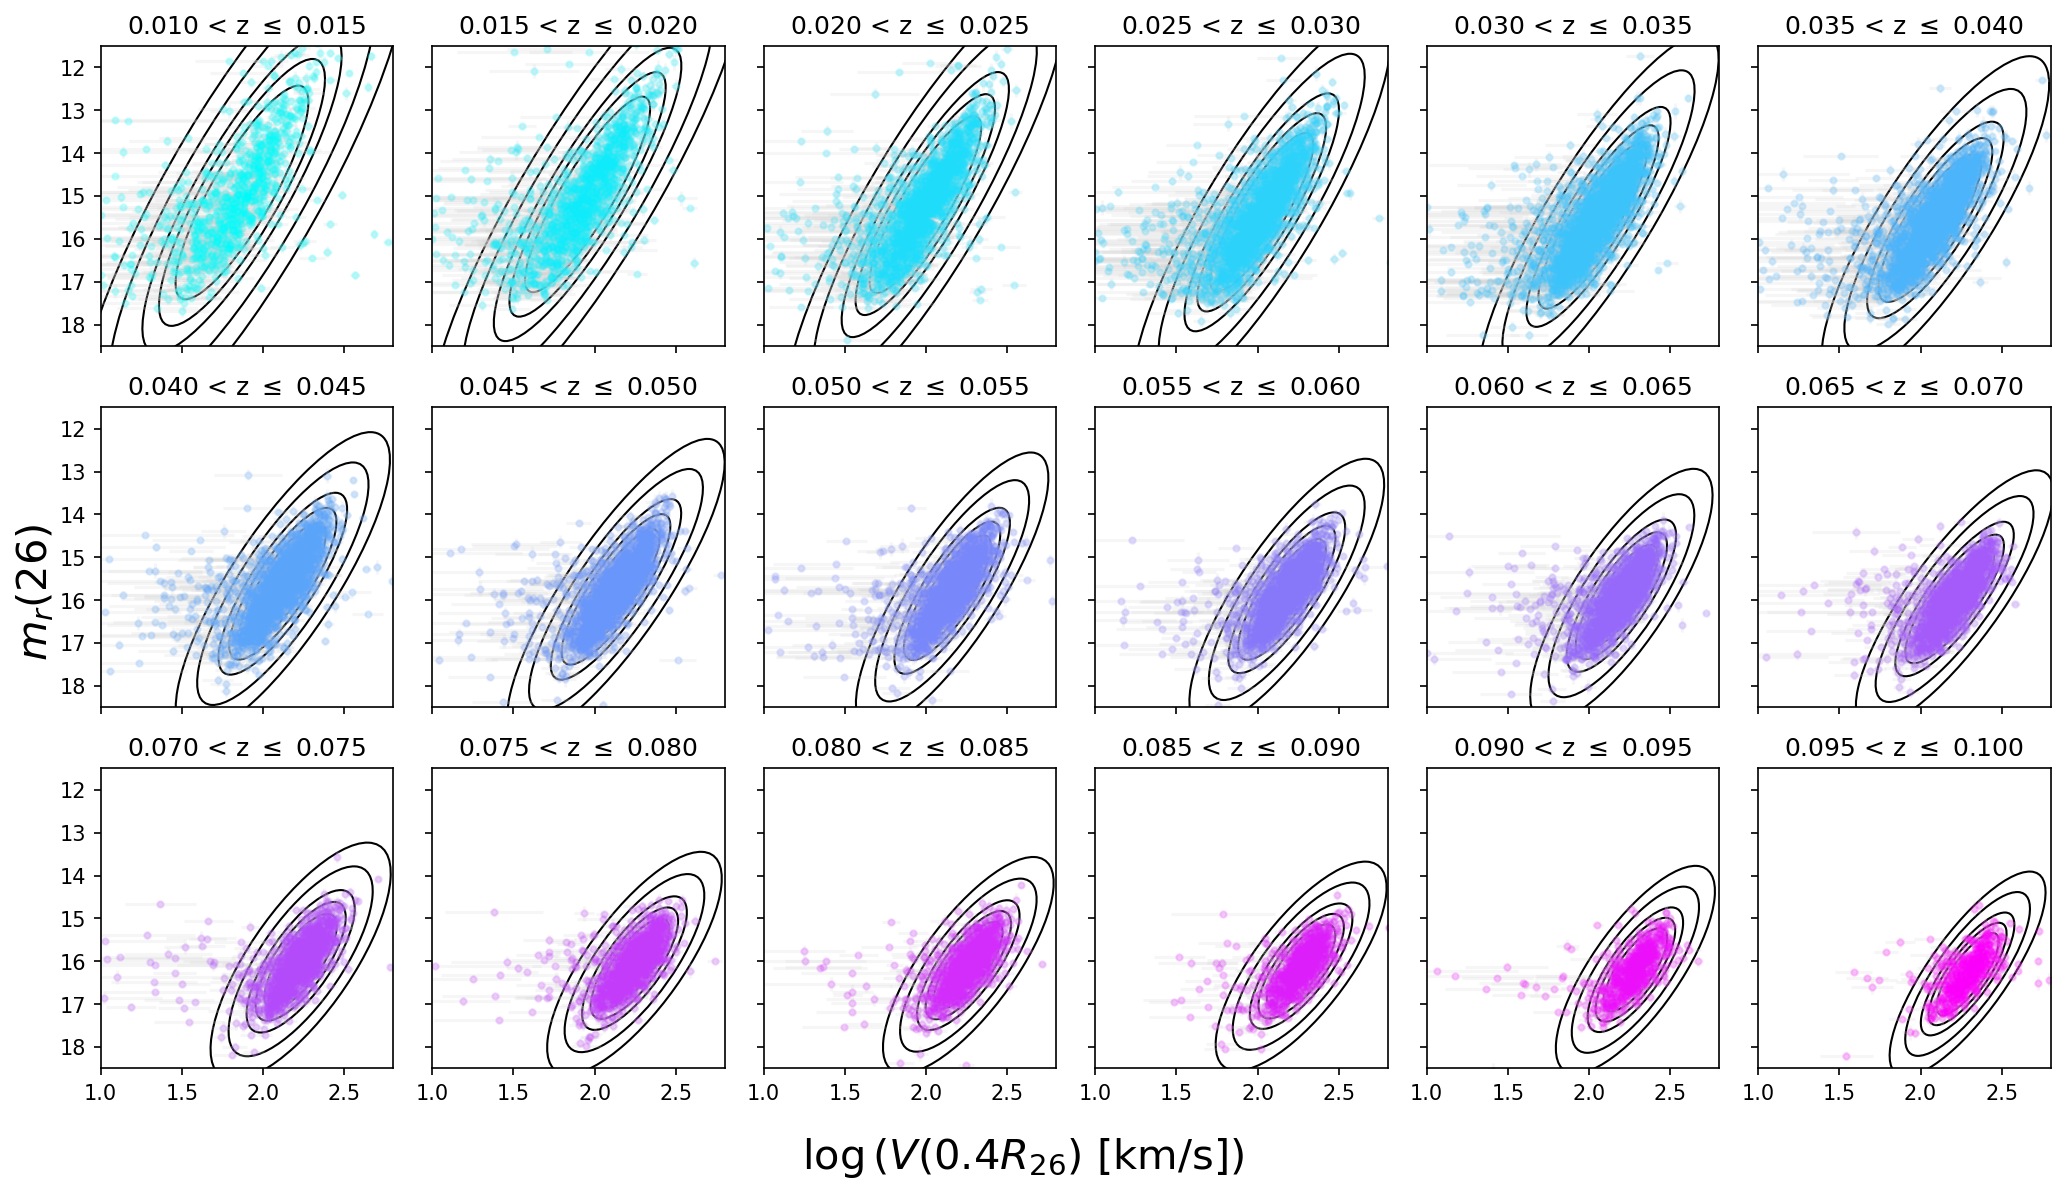

In [84]:
ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 5, ax=axs[row,col], edgecolor='k', facecolor='none')
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2.5, ax=axs[row,col], edgecolor='k', facecolor='none')
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 3, ax=axs[row,col], edgecolor='k', facecolor='none')
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 4, ax=axs[row,col], edgecolor='k', facecolor='none')
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = 2, ax=axs[row,col], edgecolor='k', facecolor='none')

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/v7_bin_ellipses_prefit.png', 
#             dpi=150, 
#             facecolor='none')


In [85]:
# sigma=2.5

zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

outlier_boolean = np.zeros(len(sgatab), dtype=bool)

# ## do the lowest and highest bins separately since they are in absmag space
bin_mask = (zbin_indices == 0)
x = np.log10(sgatab['V_0p4R26'][bin_mask])
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

for i in range(1,len(zbins)):
    bin_mask = (zbin_indices == i)

    x = np.log10(sgatab['V_0p4R26'][bin_mask])
    y = sgatab['R_MAG_SB26_CORR'][bin_mask]

    # Outliers *within this bin*
    outlier_bin = ellipse_boolean(x, y, sigma)

    # Write results back into global array
    outlier_boolean[bin_mask] = outlier_bin

bin_mask = (zbin_indices == len(zbins))
x = np.log10(sgatab['V_0p4R26'][bin_mask])
y = sgatab['R_ABSMAG_SB26'][bin_mask]
outlier_bin = ellipse_boolean(x, y, sigma)
outlier_boolean[bin_mask] = outlier_bin

print(np.sum(outlier_boolean), len(outlier_boolean), np.sum(outlier_boolean)/len(outlier_boolean))

3299 35666 0.09249705601973869


In [86]:
zmin=0.01
# zmin = 0.03
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)

zbin_indices = np.digitize(sgatab['Z_DESI_CMB'][~outlier_boolean], zbins, right=True)

binwidth=dz

for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010  749 galaxies
 1  0.010 < z <= 0.015  755 galaxies
 2  0.015 < z <= 0.020  1185 galaxies
 3  0.020 < z <= 0.025  1734 galaxies
 4  0.025 < z <= 0.030  2215 galaxies
 5  0.030 < z <= 0.035  2616 galaxies
 6  0.035 < z <= 0.040  2365 galaxies
 7  0.040 < z <= 0.045  2251 galaxies
 8  0.045 < z <= 0.050  1968 galaxies
 9  0.050 < z <= 0.055  1938 galaxies
10  0.055 < z <= 0.060  1801 galaxies
11  0.060 < z <= 0.065  1814 galaxies
12  0.065 < z <= 0.070  1749 galaxies
13  0.070 < z <= 0.075  1460 galaxies
14  0.075 < z <= 0.080  1401 galaxies
15  0.080 < z <= 0.085  1315 galaxies
16  0.085 < z <= 0.090  980 galaxies
17  0.090 < z <= 0.095  702 galaxies
18  0.095 < z <= 0.100  561 galaxies
19  z > 0.100  2808 galaxies


## Apply other cuts

In [87]:
#- Inclination cut
cosi2 = (sgatab['BA']**2 - q0**2) / (1 - q0**2)
i_min = 45. * u.degree
cosi2_max = np.cos(i_min)**2
is_good_incl = cosi2 < cosi2_max

#- Morphology cut: only ML
is_good_morph_ML = np.zeros_like(is_good_incl, dtype=bool)
for i in range(len(sgatab)):
    if sgatab['MORPHTYPE_AI'][i] == 'Spiral':
        is_good_morph_ML[i] = True

#- John's VI
is_good_John = sgatab['JOHN_VI'].mask

#- Combine selections:
is_good_sga = is_good_incl & is_good_morph_ML & is_good_John & ~outlier_boolean

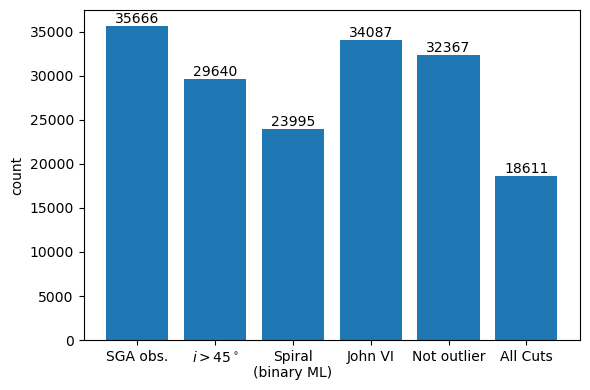

In [88]:
data = {
    'SGA obs.' : len(sgatab),
    # r'$10 < V_\mathrm{rot} < 1000$' : np.sum(is_good_velo),
    # r'$\Delta V/V_\mathrm{min}>5$' : np.sum(is_good_dv),
    r'$i > 45^\circ$' : np.sum(is_good_incl), 
    # 'Spiral' : np.sum(is_good_morph),
    'Spiral\n(binary ML)' : np.sum(is_good_morph_ML),
    'John VI' : np.sum(is_good_John), 
    # 'Not dwarf' : np.sum(~dwarf_boolean), 
    'Not outlier' : np.sum(~outlier_boolean), 
    'All Cuts' : np.sum(is_good_sga), 
    # 'All Cuts\n(binary ML)' : np.sum(is_good_sga_ML)
}
names = list(data.keys())
values = list(data.values())

fig, ax = plt.subplots(1, 1, figsize=(6,4), tight_layout=True)
bars = ax.bar(names, values, color='tab:blue')
ax.bar_label(bars, fmt='%d')
ax.set(ylabel='count');#, yscale='log', ylim=[1e3,1.2e4]);

# fig.savefig('../../Figures/Y1/TF_Y1_SGA_Vrot_cuts.png', dpi=150, facecolor='none');

In [89]:
sgatab_sel = sgatab[is_good_sga]
zbin_indices = np.digitize(sgatab_sel['Z_DESI_CMB'], zbins, right=True)

In [90]:
for i in range(len(zbins) + 1):
    if i == 0:
        print(f'{i:2d}  z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    elif i == len(zbins):
        print(f'{i:2d}  z > {zbins[i-1]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')
    else:
        print(f'{i:2d}  {zbins[i-1]:0.3f} < z <= {zbins[i]:0.3f}  {np.sum(zbin_indices == i):3d} galaxies')

 0  z <= 0.010   90 galaxies
 1  0.010 < z <= 0.015  242 galaxies
 2  0.015 < z <= 0.020  447 galaxies
 3  0.020 < z <= 0.025  740 galaxies
 4  0.025 < z <= 0.030  1098 galaxies
 5  0.030 < z <= 0.035  1387 galaxies
 6  0.035 < z <= 0.040  1256 galaxies
 7  0.040 < z <= 0.045  1248 galaxies
 8  0.045 < z <= 0.050  1124 galaxies
 9  0.050 < z <= 0.055  1155 galaxies
10  0.055 < z <= 0.060  1101 galaxies
11  0.060 < z <= 0.065  1155 galaxies
12  0.065 < z <= 0.070  1115 galaxies
13  0.070 < z <= 0.075  974 galaxies
14  0.075 < z <= 0.080  921 galaxies
15  0.080 < z <= 0.085  925 galaxies
16  0.085 < z <= 0.090  696 galaxies
17  0.090 < z <= 0.095  503 galaxies
18  0.095 < z <= 0.100  376 galaxies
19  z > 0.100  2058 galaxies


In [91]:
_, counts = np.unique(zbin_indices, return_counts=True)

print(np.min(counts[1:-1]), np.max(counts[1:-1]))

242 1387


# Build the Calibration Table of SGA Galaxies

In [92]:
sgatab_sel['Z_BIN_IDX'] = zbin_indices

no_use = (zbin_indices == 0) | (zbin_indices == len(zbins))
caltab = sgatab_sel[~no_use]

rejtab = sgatab_sel[no_use]

# caltab.write('SGA-2020_iron_Vrot_cluster_calib_z0p1_Anthony2_dVsys.fits', overwrite=True)
caltab[['Z_BIN_IDX', 'Z_DESI_CMB', 'SGA_ID', 'R_MAG_SB26_CORR', 'R_MAG_SB26_ERR_CORR', 'V_0p4R26', 'V_0p4R26_ERR']]

Z_BIN_IDX,Z_DESI_CMB,SGA_ID,R_MAG_SB26_CORR,R_MAG_SB26_ERR_CORR,V_0p4R26,V_0p4R26_ERR
int64,float64,float64,float64,float64,float64,float64
18,0.09583935447193448,32.0,15.475734646579623,0.13234981016091993,242.31732801933134,16.54634325367257
15,0.08162267561348635,38.0,16.943537400959432,0.13361490427350428,122.10002350181783,11.083695138559762
18,0.09910672096429418,53.0,16.343658835513892,0.09388462142280865,237.8295282238147,13.626207831733897
8,0.045082555650847844,55.0,17.150481296321377,0.10846211329218215,82.13538814803135,6.545709540239008
8,0.04576245512250576,63.0,16.379688388854266,0.16325676928664218,88.8936079327865,5.555616071085428
6,0.039043626012540855,74.0,16.0340261644125,0.20054971863002308,92.43620953305918,10.058848311627909
10,0.055628906754008556,76.0,16.216555037330835,0.11055099423961041,131.8828514760183,12.057273071223419
17,0.09120767170112742,117.0,16.15585258799605,0.13854330442033155,183.08805286733877,13.069447860341656
7,0.04427201534577052,149.0,15.764151984307357,0.08336590469221816,166.06262670686112,13.162650996626033


# Apply the Joint TFR Fit

In [93]:
#- Extract successful clusters
_zbin_ids = np.unique(caltab['Z_BIN_IDX'])
m = len(_zbin_ids)

#- Pack the results into arrays data and cov.
logV, logV_err = [], []
mag, mag_err = [], []
weights = []

logV0 = np.median(np.log10(caltab['V_0p4R26']))
print('logV0 =', logV0)

#- Loop over the redshift bins
for k, _zbin_id in enumerate(_zbin_ids):
    select_zbin = np.isin(caltab['Z_BIN_IDX'], _zbin_id)
    logV.append(np.log10(caltab['V_0p4R26'][select_zbin]) - logV0)
    logV_err.append(0.434*caltab['V_0p4R26_ERR'][select_zbin] / caltab['V_0p4R26'][select_zbin])
    mag.append(caltab['R_MAG_SB26_CORR'][select_zbin])
    mag_err.append(caltab['R_MAG_SB26_ERR_CORR'][select_zbin])
    weights.append(np.array(1/caltab['MAX_VOL_FRAC'][select_zbin]))

logV0 = 2.1638015723234107


## Multiline Fit using HyperFit

In [94]:
bounds = [[-20, 0]]                    # Bounds on a (slope)
bounds += m*[(-20, 20)]                # Bounds on b (intercepts: z-bins)
bounds += [(0,5)]                      # Bounds on sigma

results = hyperfit_line_multi(logV, mag, logV_err, mag_err, bounds, weights=weights, scatter=1)

a, b, sig_tfr, cov_tfr, tfr_mcmc_samples, hf_tfr = results

     fun: -19815350.602961093
     jac: array([ 2.64123084e+02,  1.53854477e+02, -1.22934570e+01, -4.56720553e+02,
        2.55182364e+02, -2.66358234e+02, -7.33882128e+01, -1.00582830e+01,
       -4.24683059e+01,  7.37607418e+01,  1.08033410e+01,  9.68575397e+00,
       -9.76025977e+01, -5.96046398e+00, -2.23517399e+00, -2.23517399e+00,
        9.46223658e+01,  5.14090019e+01, -9.46223658e+01,  4.24571336e+03])
 message: 'Optimization terminated successfully.'
    nfev: 63678
     nit: 210
 success: True
       x: array([-6.68844381, 13.06422337, 13.68355436, 14.17737431, 14.54533087,
       14.84651012, 15.13572554, 15.35845225, 15.5910426 , 15.79109958,
       15.97016144, 16.16372155, 16.3212736 , 16.46925716, 16.60734213,
       16.75699588, 16.85668355, 17.02239456, 17.15360251,  0.37149897])
Ndim: 20 18


100%|██████████| 1000/1000 [01:43<00:00,  9.69it/s]


Niterations/Max Iterations:  1000 / 100000
Integrated ACT/Min Convergence Iterations:  [109.95902199  38.42013998  59.97528986  48.87906721  42.1199522
  28.25898974  69.31962668  31.72373383  37.80312354  77.43065732
  68.20627378  26.838827    47.92102932  41.86838696  47.77423012
  40.45079759 123.99870942  78.86299106  91.5229152  105.68067075] / 6199.935470980089


100%|██████████| 1000/1000 [01:42<00:00,  9.72it/s]


Niterations/Max Iterations:  2000 / 100000
Integrated ACT/Min Convergence Iterations:  [ 87.58722478  52.19751492  37.33902259  40.66623603  24.76540612
  35.17568024  30.54224908  24.7301904   59.16222231  66.04558616
  59.66521743  31.22028308  39.28597176  59.17612177  52.3761722
  72.77587805  86.31351134  73.09844144 104.40659067  92.46617427] / 5220.329533572019


...

Niterations/Max Iterations:  31000 / 100000
Integrated ACT/Min Convergence Iterations:  [127.27909489  90.41135521  39.65308078  29.47073309  33.10209198
  26.67241294  30.50705512  27.11564125  40.88089613  58.40631963
  53.16581423  73.23233295  63.35764047 101.38741365  88.97043114
  89.93198391 113.61559478 242.12349655 146.30228408 261.78390211] / 13089.19510550833


100%|██████████| 1000/1000 [01:35<00:00, 10.51it/s]


Niterations/Max Iterations:  32000 / 100000
Integrated ACT/Min Convergence Iterations:  [135.31046552  85.80990799  35.45150464  29.98418928  33.06155536
  26.36136132  30.14127306  27.0544869   41.51641247  57.99427472
  53.03900811  71.94822028  63.18063827 102.19328776  88.48418762
  90.38043545 110.97088855 177.9167814  164.21975222 280.16665158] / 14008.332578873229


100%|██████████| 1000/1000 [01:36<00:00, 10.37it/s]


Niterations/Max Iterations:  33000 / 100000
Integrated ACT/Min Convergence Iterations:  [130.46942035  83.16120342  35.15882756  30.1451731   33.25700916
  25.99104633  29.65236449  26.71518406  41.11118547  58.44875966
  52.28693656  70.77687616  63.17883546  98.21523641  91.96129445
  88.75196466 112.96325995 176.66422871 156.89011692 267.42331345] / 13371.165672317631


In [45]:
temp_outfile = open('/pscratch/sd/s/sgmoore1/TF/pickles/Y3/cov_ab_loa_jointTFR_ellipse_v3.pickle', 
                    'wb')
pickle.dump((cov_tfr, tfr_mcmc_samples, logV0, zmin, zmax, dz, zbins), temp_outfile)
temp_outfile.close()

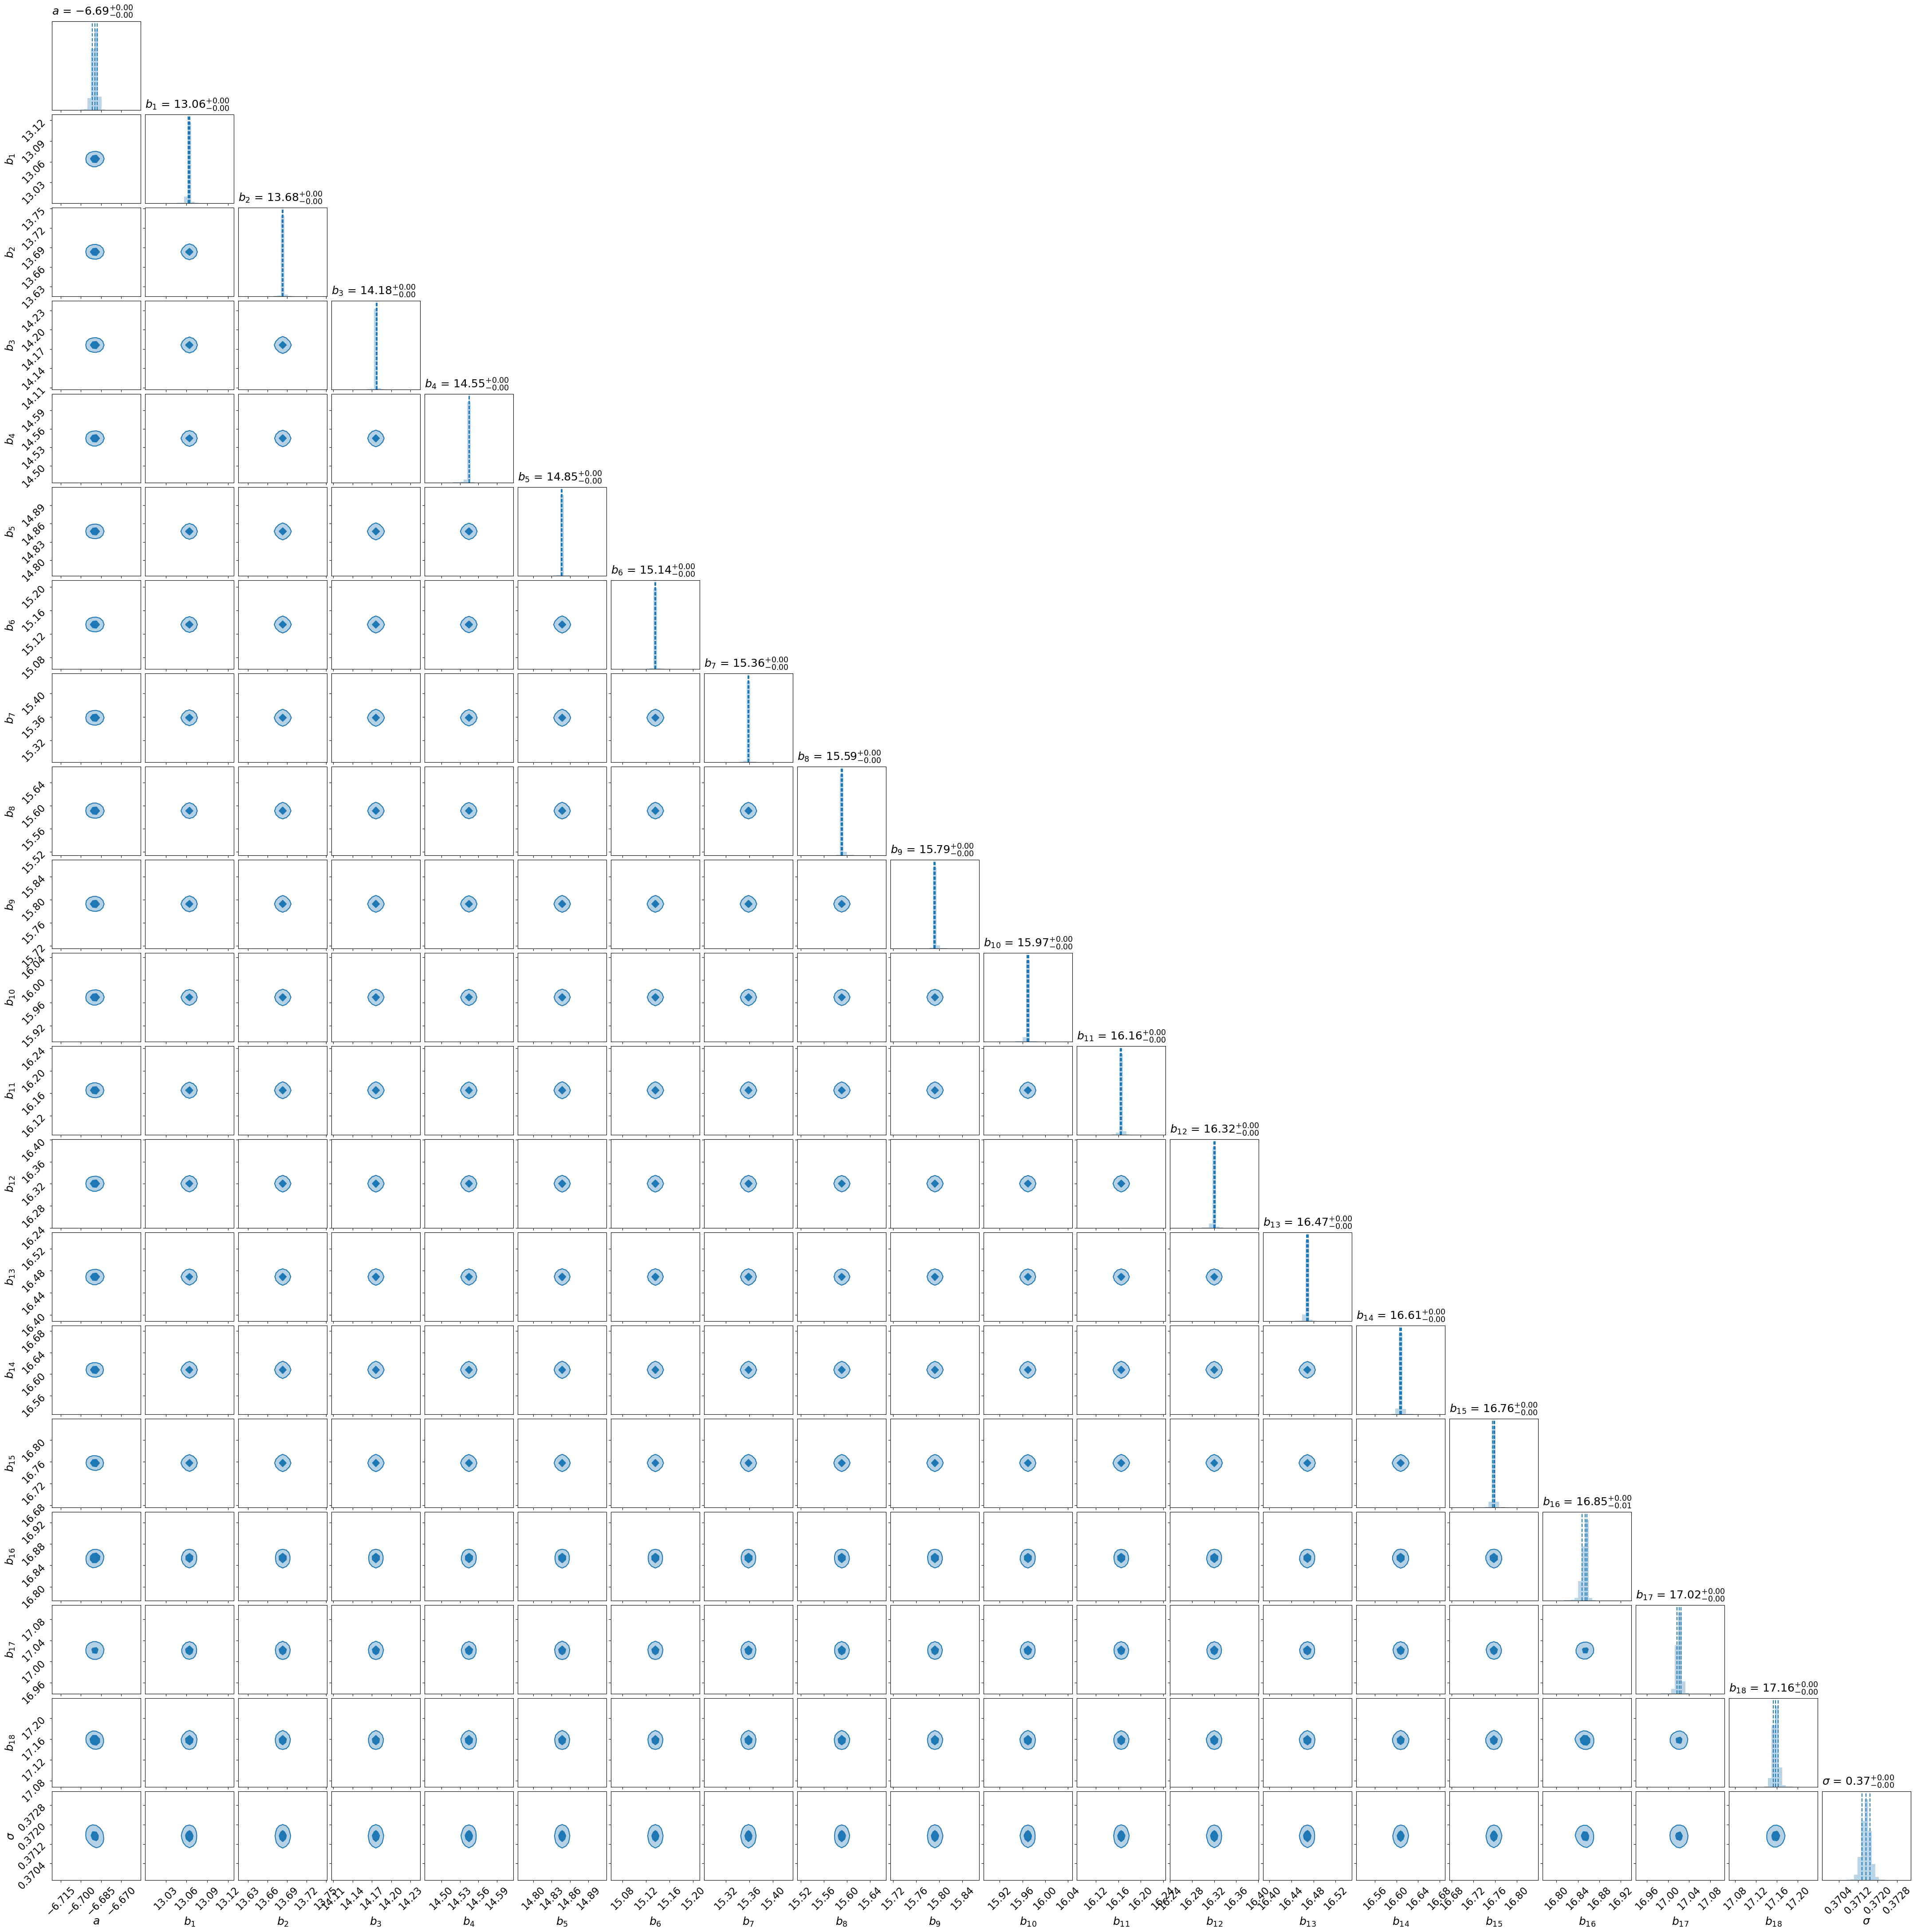

In [95]:
labels  = ['$a$']
labels += [f'$b_{{ {k+1} }}$' for k in np.arange(m)]
labels += [r'$\sigma$'] #+ [rf'$\sigma_{k}$' for k in np.arange(m)]

fig = corner(tfr_mcmc_samples.T, bins=25, smooth=1,
#              range=[[1.9, 2.4], [0.75, 1.1], [0.1, 0.3]],   # Range for a, b, sigma. Adjust as needed.
             labels=labels,
             label_kwargs={'fontsize':18},
             labelpad=0.1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             quantiles=[0.16, 0.5, 0.84],
             color='tab:blue',
             hist_kwargs={'histtype':'stepfilled', 'alpha':0.3},
             plot_datapoints=False,
             fill_contours=True,
             show_titles=True,
             title_kwargs={"fontsize": 18, 'loc':'left', 'pad':10});

for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=16)

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_corner0_20250717.png', 
#             dpi=150, 
#             facecolor='none');

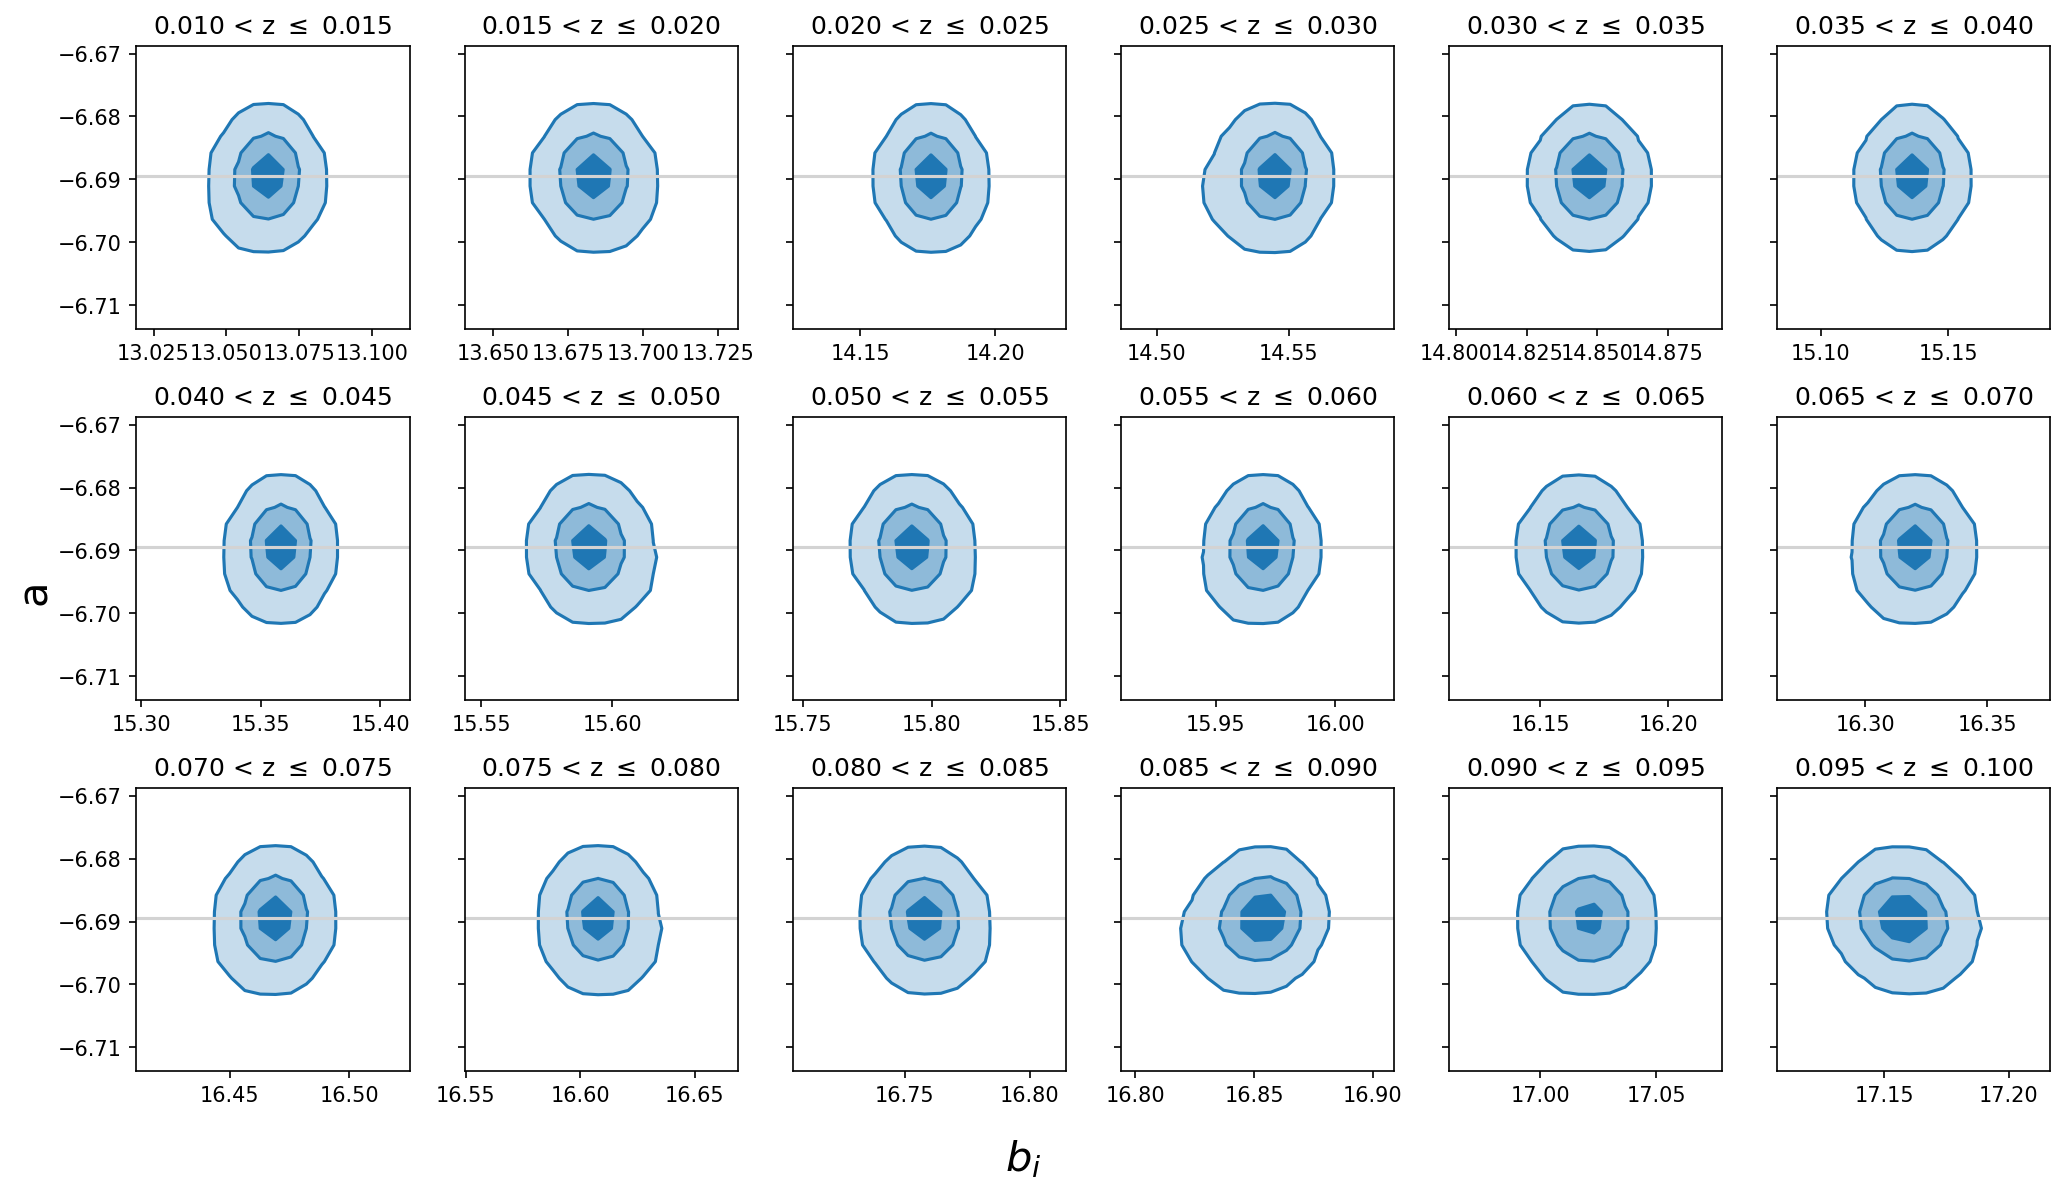

In [96]:
samples = tfr_mcmc_samples.T
a = samples[:, 0]
b_vals = samples[:, 1:-1]
n_b = b_vals.shape[1]
ncols = 6
nrows = 3
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=False, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)

axs = np.array(axs).reshape(-1)

for i in range(n_b):
    ax = axs[i]

    hist2d(
        b_vals[:, i],
        a,
        ax=ax,
        bins=25,
        smooth=1,
        levels=(1-np.exp(-0.5), 1-np.exp(-2), 1-np.exp(-4.5)),
        plot_datapoints=False,
        fill_contours=True,
        color='tab:blue'
    )
    ax.axhline(np.median(a), color='lightgray')

    ax.set(
        xlim = np.percentile(b_vals[:, i], [0.05,99.95]),
        ylim = np.percentile(a, [0.05,99.95]),
        title=f'{zbins[i]:.3f} < z $\\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}'
    )

    # if i % ncols == 0:
    #     ax.set_ylabel(f'$b_{{{i+1}}}$', fontsize=14)
    # if i >= (nrows-1)*ncols:
    #     ax.set_xlabel('$a$', fontsize=14)


# turn off unused axes
for j in range(n_b, len(axs)):
    axs[j].axis('off')

fig.supxlabel(r'$b_i$', fontsize=20)
fig.supylabel('a', fontsize=20)

plt.tight_layout()
# plt.show()

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v2_fit_contours.png', 
#             dpi=150, 
#             facecolor='none')


### Plot the HyperFit Results

In [97]:
sigma_mcmc = np.percentile(tfr_mcmc_samples[-1], [16., 50., 84.])
a_mcmc = np.percentile(tfr_mcmc_samples[0], [16., 50., 84])
b_mcmc = []
# for k in range(1, m+2):
for k in range(1, m+1):
    b_mcmc.append(np.percentile(tfr_mcmc_samples[k], [16., 50., 84.]))
b_mcmc = np.asarray(b_mcmc)

In [98]:
i=0
while i < 20:
    print(f'{np.mean(tfr_mcmc_samples[i]):.4f}, {np.sqrt(cov_tfr[i,i]):.4f}')
    i+=1

-6.6896, 0.0023
13.0638, 0.0033
13.6836, 0.0032
14.1772, 0.0034
14.5446, 0.0039
14.8465, 0.0031
15.1358, 0.0034
15.3582, 0.0038
15.5915, 0.0038
15.7918, 0.0038
15.9695, 0.0040
16.1645, 0.0038
16.3206, 0.0041
16.4688, 0.0041
16.6076, 0.0044
16.7577, 0.0043
16.8527, 0.0062
17.0211, 0.0056
17.1579, 0.0060
0.3715, 0.0002


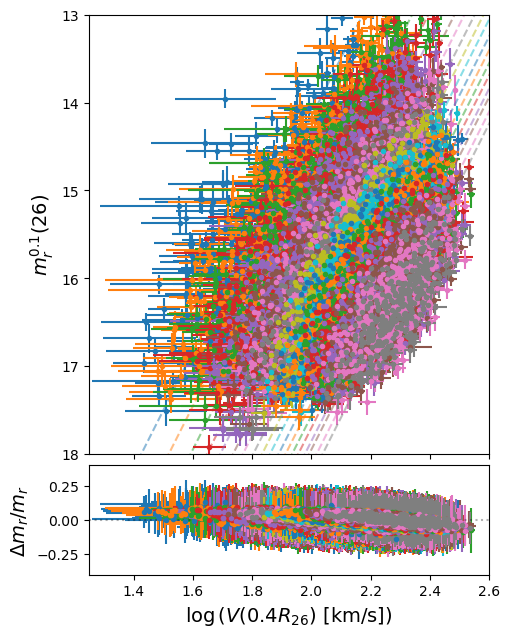

In [99]:
# fig, axes = plt.subplots(2,2, figsize=(10,7), sharex=True,
fig, axes = plt.subplots(2,1, figsize=(5,7), sharex=True,
                         gridspec_kw={'height_ratios':[4,1], 'hspace':0.04, 'wspace':0.25})

a_   = a_mcmc[1]
# b0pt = b_mcmc[0,1]
b_   = b_mcmc[:,1]#[1:]

#- Plot redshift bins
# ax = axes[0,0]
ax = axes[0]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

_logv = np.arange(0, 3, 0.1) - logV0
for k in range(m):
    eb = ax.errorbar(x=logV0 + logV[k],#+1], 
                     y=mag[k],#+1], 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.', 
                     label=f'{zbins[k]:.3f}-{zbins[k+1]:.3f}')

    ax.plot(_logv + logV0, a_*_logv + b_[k], color=eb[0].get_color(), ls='--', alpha=0.5)

ax.set(xlim=[1.25, 2.6],
       ylim=[18, 13])
ax.set_ylabel(r'$m_r^{0.1} (26)$', fontsize=14)
# ax.legend(loc='upper left', fontsize=9, ncol=2);
'''
#- Plot calibrators
ax = axes[0,1]
eb = ax.errorbar(x=logV[0] + logV0, y=mag[0], xerr=logV_err[0], yerr=mag_err[0],
                 fmt='.', color='tab:blue', label=f'0-pt')

ax.plot(_logv + logV0, a_*_logv + b0pt, color=eb[0].get_color(), ls='--')#, label='fit')
ax.set(xlim=[1.25, 2.6],
       ylim=[-18, -24]
      )
ax.set_ylabel(r'$M_r^{0.1}(26) = m_r^{0.1}(26) - \mu$', fontsize=14)
ax.legend(loc='upper left', fontsize=9, ncol=2)
'''
#- Plot residuals: z-bins
# ax = axes[1,0]
ax = axes[1]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', plt.cm.viridis(np.linspace(0,1,m)))

for k in range(m):
    logv_obs = logV[k]#+1]
    m_obs = mag[k]#+1]
    m_exp = (a_*logv_obs + b_[k])
    eb = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                     xerr=logV_err[k],#+1], 
                     yerr=mag_err[k],#+1],
                     fmt='.')

ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta m_r/m_r$', fontsize=14)
'''
#- Plot residuals: calibrators
ax = axes[1,1]

logv_obs = logV[0]
m_obs = mag[0]
m_exp = (a_*logv_obs + b0pt)

b = ax.errorbar(x=logv_obs + logV0, y=(m_exp-m_obs)/m_exp, 
                xerr=logV_err[0], yerr=mag_err[0],
                fmt='.', color='tab:blue')
ax.axhline(0, ls=':', color='k', alpha=0.3)

ax.set(xlim=[1.25, 2.6],
       ylim=[-0.4, 0.4])
ax.set_xlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=14)
ax.set_ylabel(r'$\Delta M_r/M_r$', fontsize=14)
'''
fig.subplots_adjust(left=0.1, bottom=0.1, top=0.9, right=0.9);

# fig.savefig('../../Figures/Y1/TF_Y1_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

In [100]:
print(f'slope (alpha): {-a_/2.5:.2f} +/- {np.sqrt(cov_tfr[0,0])/2.5:.3f}')

slope (alpha): 2.68 +/- 0.001


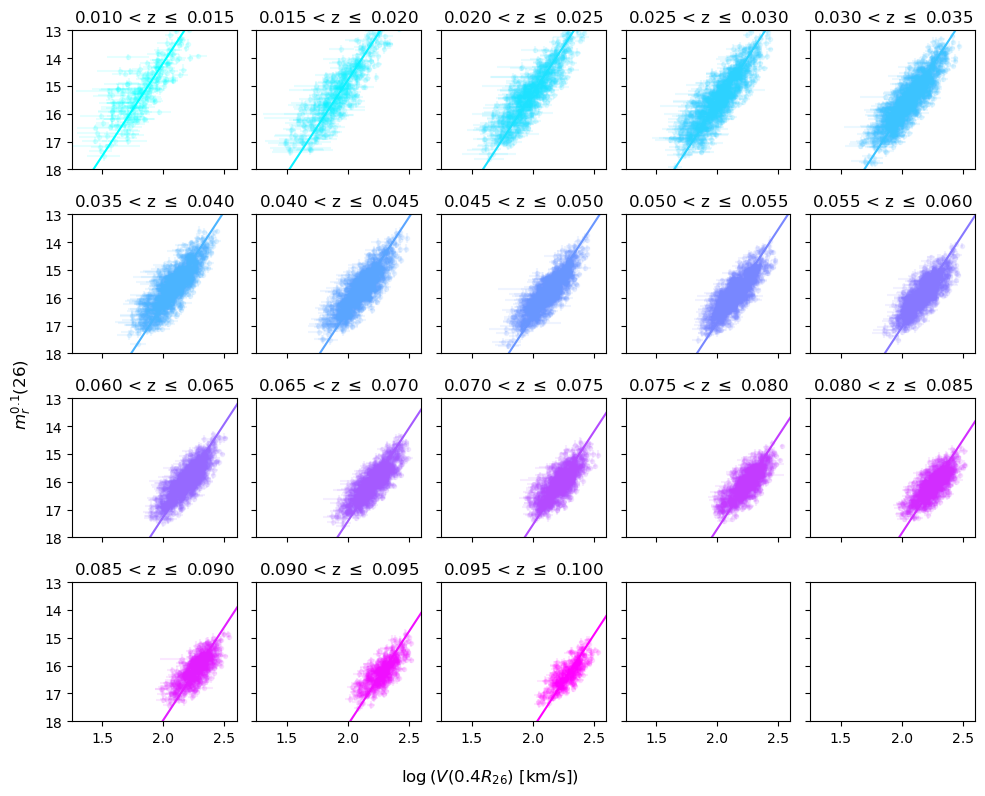

In [101]:
# fig, axs = plt.subplots(nrows=7, ncols=10, sharex=True, sharey=True, figsize=(20,16), tight_layout=True)
fig, axs = plt.subplots(nrows=4, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)

color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/5)
    col = i%5
    
    eb = axs[row,col].errorbar(logV0 + logV[i],#+1], 
                               mag[i],#+1], 
                               xerr=logV_err[i],#+1], 
                               yerr=mag_err[i],#+1], 
                               fmt='.', color=c, alpha=0.1)
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    
    axs[row,col].set(xlim=[1.25, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {zbins[i+1]:.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)')
fig.supylabel(r'$m_r^{0.1} (26)$');

# plt.savefig('../../Figures/Y1/TF_Y1_individual_cluster_calibration_0pt_binaryMLupdated_z0p1_Anthony2_weightsVmax-1_dVsys_fit0_20250717.png', 
#             dpi=150, 
#             facecolor='none')

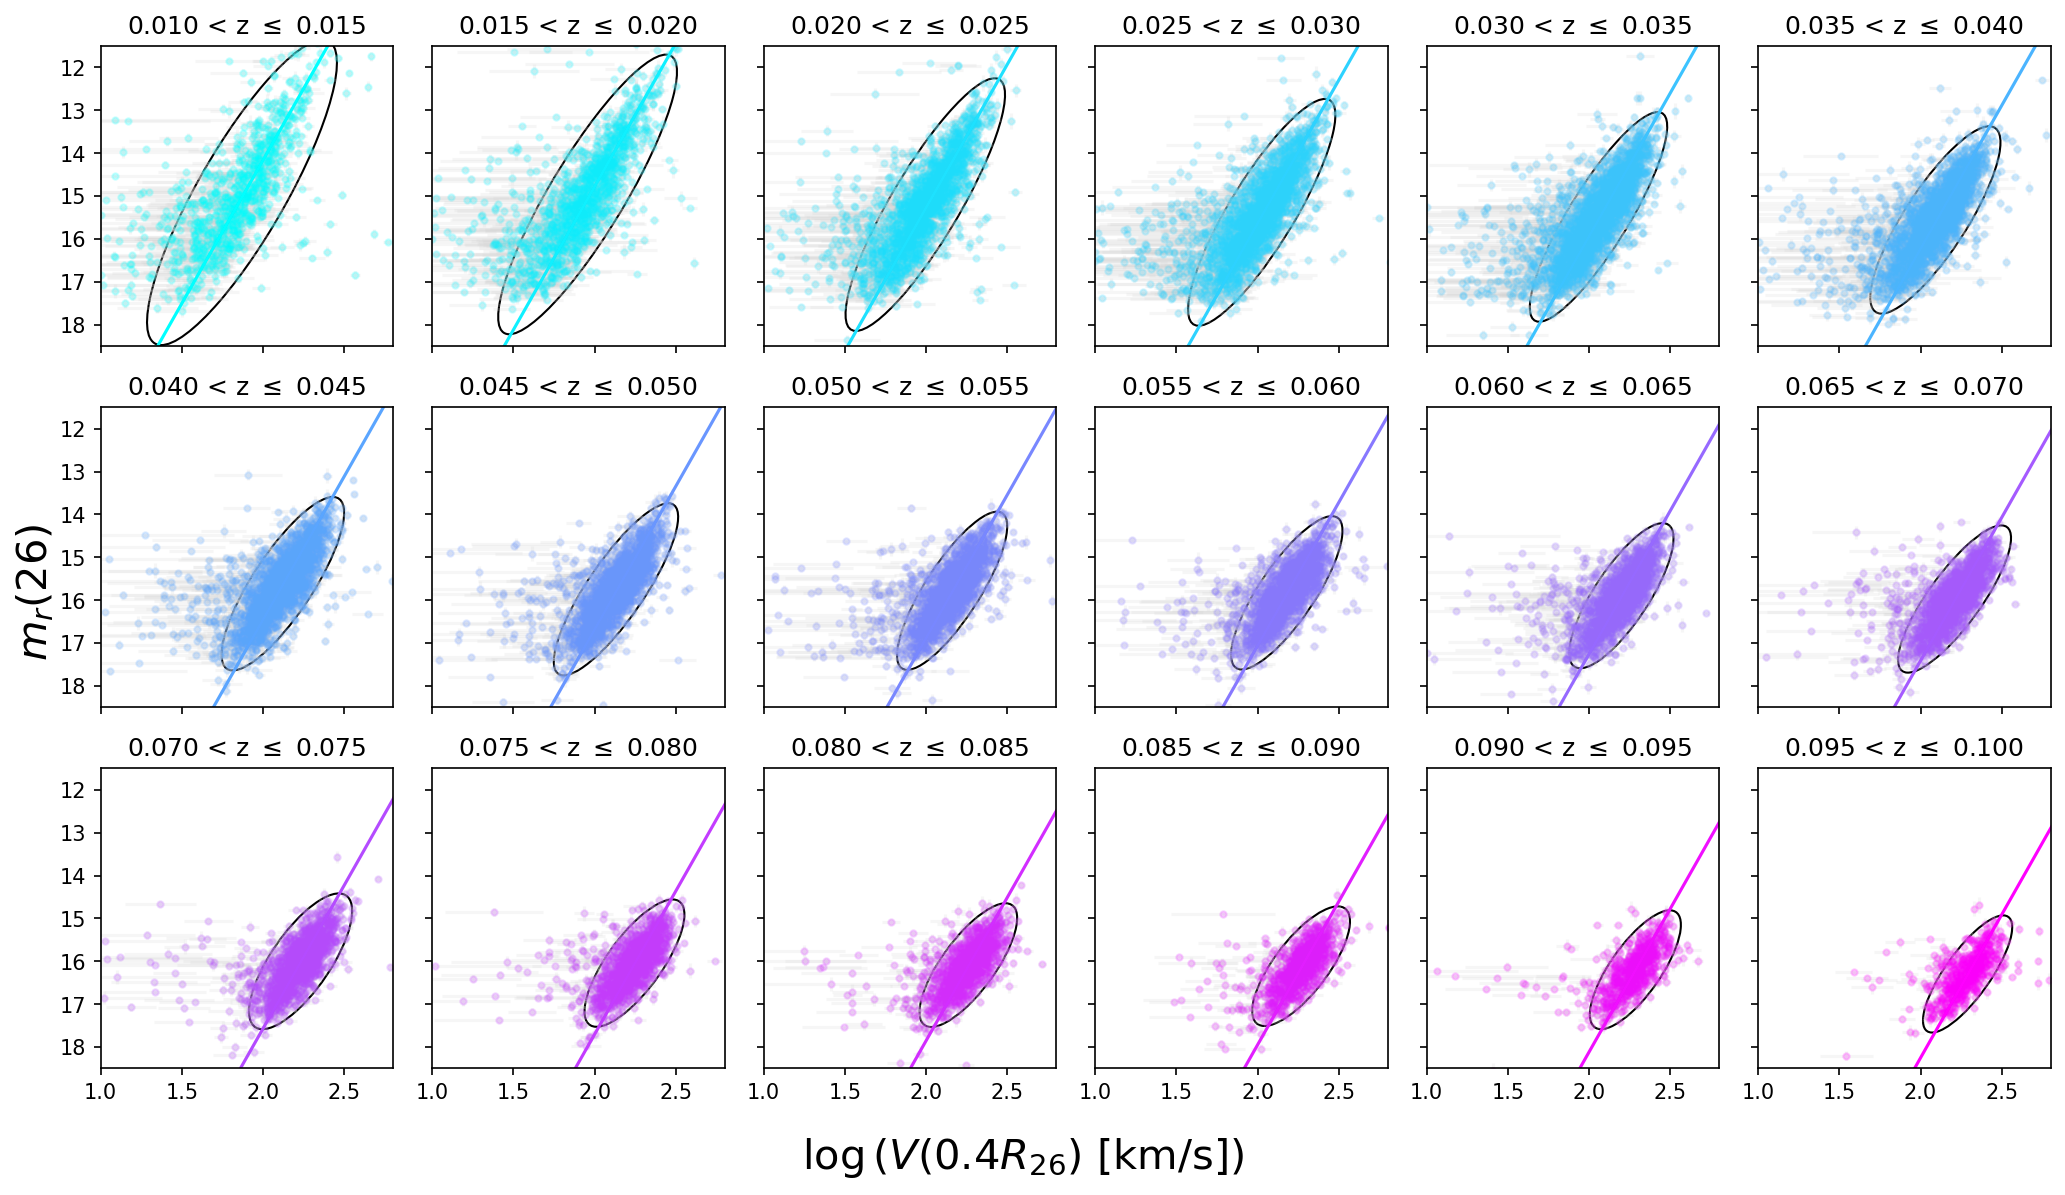

In [102]:
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

ncols=6
fig, axs = plt.subplots(nrows=3, ncols=ncols, sharex=True, sharey=True, figsize=(14,8), tight_layout=True,
                        facecolor='none', dpi=150)
# fig, axs = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10,8), tight_layout=True)
m = len(mu_x)
color = iter(plt.cm.cool(np.linspace(0,1,m)))
for i in range(m):
    c = next(color)
    
    row = int(i/ncols)
    col = i%ncols
    
    eb = axs[row,col].errorbar(np.log10(sgatab['V_0p4R26'][zbin_indices==i+1]),#+1], 
                               sgatab['R_MAG_SB26_CORR'][zbin_indices==i+1],#+1], 
                               xerr=0.43*sgatab['V_0p4R26_ERR'][zbin_indices==i+1]/sgatab['V_0p4R26'][zbin_indices==i+1],#+1], 
                               yerr=sgatab['R_MAG_SB26_ERR_CORR'][zbin_indices==i+1],#+1], 
                               fmt='.', color=c, ecolor='lightgray', alpha=0.2)
    # axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    plot_ellipse(mean=(mu_x[i], mu_y[i]), cov = ([cov_xx[i], cov_xy[i]],[cov_yx[i], cov_yy[i]]),
                 n_std = sigma, ax=axs[row,col], edgecolor='k', facecolor='none')

    
    # axs[row,col].set(xlim=[1.5, 2.6], ylim=[18, 13], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')
    axs[row,col].plot(_logv + logV0, a_*_logv + b_[i], color=c)
    axs[row,col].set(xlim=[1, 2.8], ylim=[18.5, 11.5], title=f'{zbins[i]:.3f} < z $\leq$ {(zbins[i+1] if i+2 < len(zbins) else zmax):.3f}')

# Delete extra axes
# fig.delaxes(axs[-1,-1])

fig.supxlabel(r'$\log{(V(0.4R_{26})~[\mathrm{km/s}]}$)', fontsize=20)
fig.supylabel(r'$m_r (26)$', fontsize=20);

plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_v3_bin_ellipses_postfit.png', 
            dpi=150, 
            facecolor='none')


# Calculate logdistance ratios

In [103]:
cosmo = FlatLambdaCDM(H0=H0, Om0=0.3151)
# cosmo = DESI()

sgatab['MU_ZCMB'] = cosmo.distmod(sgatab['Z_DESI_CMB'])

sgatab['R_ABSMAG_SB26'] = sgatab['R_MAG_SB26_CORR'] - sgatab['MU_ZCMB'].value

In [104]:
rng = np.random.default_rng()

N_samples = 1000

mu_err = np.empty(len(sgatab['MU_ZCMB']))*u.mag

for i in tqdm(range(len(mu_err))):
    
    z_desi_random = rng.normal(np.abs(sgatab['Z_DESI_CMB'][i]), 
                               sgatab['ZERR_DESI'][i], 
                               N_samples)
    
    mu_random = cosmo.distmod(z_desi_random)
    
    mu_err[i] = np.std(mu_random)

sgatab['MU_ZCMB_ERR'] = mu_err

sgatab['R_ABSMAG_SB26_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['MU_ZCMB_ERR'].value**2)

100%|██████████| 35666/35666 [00:36<00:00, 965.83it/s] 


In [105]:
# Center redshift values of each bin
zmin = 0.01
zmax = 0.1
dz = 0.005
zbins = np.arange(zmin, zmax+dz/2, dz)
zc = 0.5*dz + zbins[:-1]

# Distance modulus for each redshift bin center
mu_zc = cosmo.distmod(zc)

In [106]:
slope = np.median(tfr_mcmc_samples[0])
slope_err = np.sqrt(cov_tfr[0,0])

# Each redshift bin has its own 0pt
# To put it in absolute-magnitude space, we'll convert it to an absolute magnitude using the middle of the redshift bin
ZP = np.median(tfr_mcmc_samples[1:-1], axis=1) - mu_zc.value
ZP_err = np.sqrt(np.diagonal(cov_tfr[1:-1,1:-1])) # Should include z-bin width to this uncertainty

sig = np.median(tfr_mcmc_samples[-1])

logv = np.linspace(-1*np.ones(len(zbins)-1), 3.5*np.ones(len(zbins)-1), 100)
absmag = slope*(logv - logV0) + ZP

In [107]:
spiral_boolean = sgatab['MORPHTYPE_AI'] == 'Spiral'
irregular_boolean = sgatab['MORPHTYPE_AI'] == 'Irregular'
# other_boolean = sgatab['MORPHTYPE_AI'] == 'Other'

VI_boolean = sgatab['JOHN_VI'].mask

morph_boolean = (spiral_boolean | irregular_boolean) & VI_boolean

In [108]:
sgatab['GOOD_MORPH'] = morph_boolean

print(sum(outlier_boolean), 'outliers')
print(sum(~outlier_boolean), 'non-outliers')
print('-----------')
print(np.sum(morph_boolean), 'spirals & irregulars that pass VI')
print(np.sum(morph_boolean & outlier_boolean), 'outliers')
print(np.sum(morph_boolean & ~outlier_boolean), 'non-outliers')

3299 outliers
32367 non-outliers
-----------
31831 spirals & irregulars that pass VI
2422 outliers
29409 non-outliers


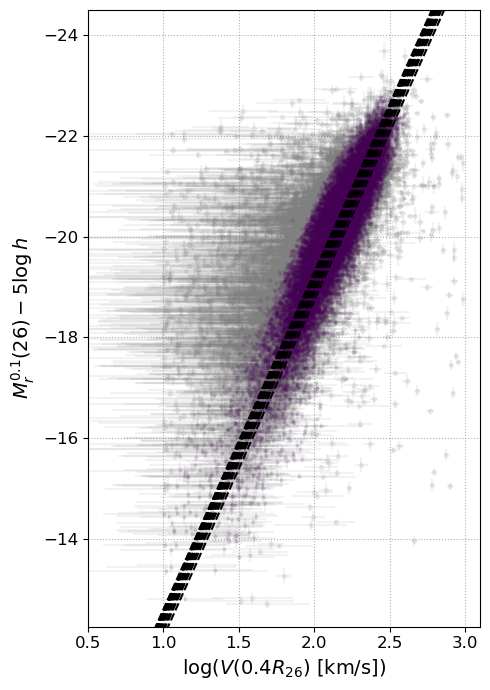

In [109]:
plt.figure(figsize=(5,7), tight_layout=True)

plt.grid(ls=':')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray')

sample = outlier_boolean# & morph_boolean
plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean# & morph_boolean
plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
             sgatab['R_ABSMAG_SB26'][sample], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
             fmt='.', 
             markersize=4, 
             alpha=0.1, 
             ecolor='gray')

# sample = ~outlier_boolean_alt & outlier_boolean
# plt.errorbar(np.log10(sgatab['V_0p4R26'][sample]), 
#              sgatab['R_ABSMAG_SB26'][sample], 
#              xerr=0.434*sgatab['V_0p4R26_ERR'][sample]/sgatab['V_0p4R26'][sample],
#              yerr=sgatab['R_ABSMAG_SB26_ERR'][sample], 
#              fmt='.', 
#              markersize=4, 
#              alpha=0.2, 
#              ecolor='gray')



plt.plot(logv, absmag, 'k--', zorder=3)

plt.xlim([0.5, 3.1])
plt.ylim([-12.25, -24.5])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r^{0.1} (26) - 5\log h$', fontsize=14);

ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=12);

# plt.savefig('../../Figures/Y1/iron_jointTFR_varyV0-perpdwarf_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none')

Text(0, 0.5, '$M_r(26)$')

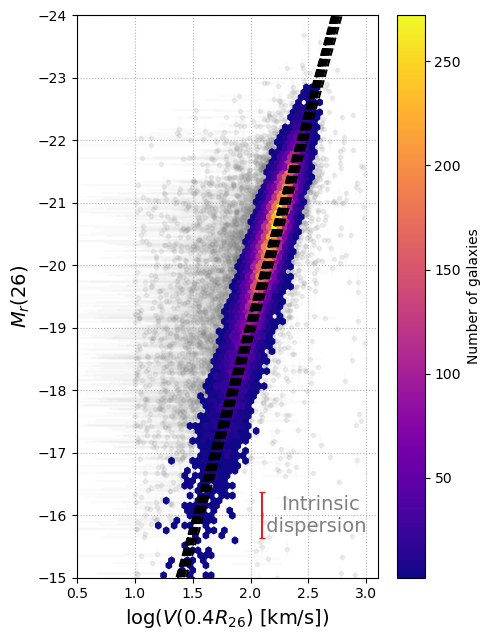

In [110]:
plt.figure(figsize=(5,6.5), tight_layout=True)
plt.grid(ls=':')

plt.errorbar(np.log10(sgatab['V_0p4R26'][outlier_boolean]), 
             sgatab['R_ABSMAG_SB26'][outlier_boolean], 
             xerr=0.434*sgatab['V_0p4R26_ERR'][outlier_boolean]/sgatab['V_0p4R26'][outlier_boolean],
             yerr=sgatab['R_ABSMAG_SB26_ERR'][outlier_boolean], 
             fmt='.',
             color='gray',
             alpha=0.1, 
             ecolor='lightgray', zorder=1)

plt.hexbin(np.log10(sgatab['V_0p4R26'][~outlier_boolean]), 
           sgatab['R_ABSMAG_SB26'][~outlier_boolean], 
           cmap='plasma', 
           mincnt=2, 
           gridsize=(70,80), 
           extent=(-0.1, 3.1, -25, -12.25), zorder=2)
plt.colorbar(label='Number of galaxies')

# plt.fill_between(logv, line_err[0], line_err[1], color='lightgray', alpha=0.2)
plt.plot(logv, absmag, 'k--', zorder=3)


plt.errorbar([2.1], [-16], 
             xerr=0,
             yerr=sig, 
             ecolor='tab:red', 
             capsize=2)
plt.annotate('Intrinsic \n dispersion', 
             (3, -16), 
             va='center',
             ha='right',
             c='gray',
             fontsize=14)

plt.xlim([0.5, 3.1])
plt.ylim([-15, -24])

plt.xlabel('log($V(0.4R_{26})$ [km/s])', fontsize=14)
plt.ylabel('$M_r(26)$', fontsize=14)

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/Y3_tfr_hexbin_hyperfit_v3.png', 
#             dpi=150, 
#             facecolor='none')

#### Redshift distribution

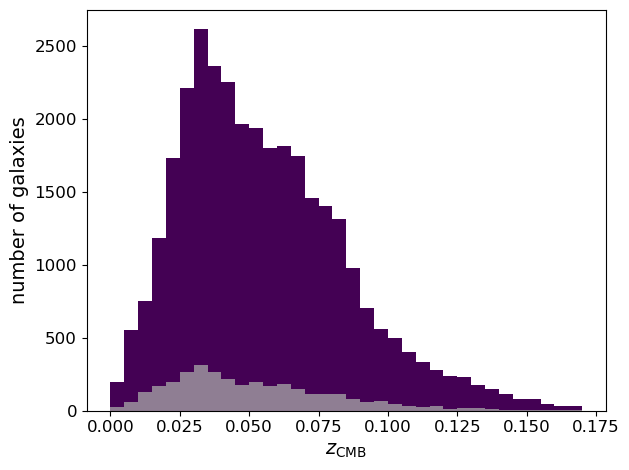

In [111]:
plt.figure(tight_layout=True)

plt.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
         bins=np.arange(0, 0.175, 0.005))
plt.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
         bins=np.arange(0, 0.175, 0.005), 
         color='darkgray',
         alpha=0.75)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel('number of galaxies', fontsize=14);

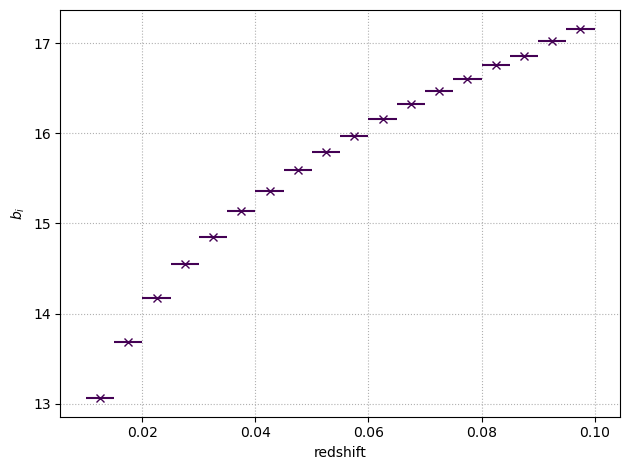

In [112]:
plt.figure(tight_layout=True)

plt.grid(ls=':')

plt.errorbar(zc, np.median(tfr_mcmc_samples[1:-1], axis=1), 
             xerr=0.5*dz, 
             yerr=ZP_err, 
             fmt='x')

# plt.xlim(0.028, 0.102)
# plt.ylim(-20.5, -20.7)

plt.xlabel('redshift')
plt.ylabel('$b_i$');

# Distance moduli

In [113]:
# First, match each galaxy to its redshift bin
zbin_indices = np.digitize(sgatab['Z_DESI_CMB'], zbins, right=True)

# For those galaxies that fall outside the calibration range, assign them to the closest bin
zbin_indices[zbin_indices == 0] = 1
zbin_indices[zbin_indices == len(zbins)] = len(zbins) - 1

# Then, use that galaxy's redshift bin's zero-point to calculate the distance modulus
sgatab['R_ABSMAG_SB26_TF'] = np.nan
for i in range(len(sgatab)):
    sgatab['R_ABSMAG_SB26_TF'][i] = slope*(np.log10(sgatab['V_0p4R26'][i]) - logV0) + ZP[zbin_indices[i] - 1]

In [114]:
sgatab['R_ABSMAG_SB26_TF_ERR'] = np.nan
sgatab['R_ABSMAG_SB26_TF_ERR_STAT'] = np.nan

rng = np.random.default_rng()

for i in tqdm(range(len(sgatab))):
    
    v_random = rng.normal(sgatab['V_0p4R26'][i], 
                          sgatab['V_0p4R26_ERR'][i], 
                          size=10000
                          # size=len(slopes)
                         )
    # logv_random = rng.normal(np.log10(sgatab['V_0p4R26'][i]), 
    #                          0.434*sgatab['V_0p4R26_ERR'][i]/sgatab['V_0p4R26'][i], 
    #                          size=len(slopes))

    ############################################################################
    # Statistical uncertainty
    #---------------------------------------------------------------------------
    Ms_stat = slope*(np.log10(v_random[v_random > 0]) - logV0) + ZP[zbin_indices[i] - 1]
    # Ms_stat = slope*(logv_random - V0) + ZP

    sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][i] = np.nanstd(Ms_stat)
    ############################################################################

    
    ############################################################################
    # Total uncertainty
    #
    # THIS NEEDS TO BE UPDATED TO INCLUDE THE SLOPE & Y-INTERCEPT UNCERTAINTIES
    #---------------------------------------------------------------------------
    # Ms = slopes[v_random > 0]*(np.log10(v_random[v_random > 0]) - V0) + ZPs[v_random > 0]
    # Ms = slopes*(logv_random - V0) + ZPs
    
    # sgatab['R_ABSMAG_SB26_TF_ERR'][i] = np.nanstd(Ms)
    sgatab['R_ABSMAG_SB26_TF_ERR'][i] = np.sqrt(sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][i]**2 + sig**2)
    ############################################################################
    

################################################################################
# Systematic uncertainty
#-------------------------------------------------------------------------------
sgatab['R_ABSMAG_SB26_TF_ERR_SYS'] = np.sqrt(sgatab['R_ABSMAG_SB26_TF_ERR']**2 - sgatab['R_ABSMAG_SB26_TF_ERR_STAT']**2)
################################################################################

100%|██████████| 35666/35666 [00:15<00:00, 2292.22it/s]


In [115]:
def profile_histogram(x, y, xbins, yerr=None, weights=None, median=False, weighted=False):
    """Compute a profile histogram from scattered data.
    
    Parameters
    ----------
    x : list or ndarray
        Ordinates (independent variable).
    y : list or ndarray
        Coordinates (dependent variable).
    xbins : list or ndarray
        Bin edges for the independent variable.
    yerr : list or ndarray
        Uncertainties on the dependent variable. Assumed independent.
    weights : list or ndarray
        If not None (and weighted=True), will use this instead of yerr to weight 
        the summary statistics.
    median : bool
        If true, compute median as central value; else, the (weighted) mean.
    weighted : bool
        Weight the summary statistics, either by the uncertainty in y or the 
        provided weights.
        
    Returns
    -------
    N : ndarray
        Unweighted counts per bin.
    h : ndarray
        Summary statistic (mean or median) of independent variable per bin.
    e : ndarray
        Uncertainty on the summary statistic per bin.
    """
    
    N = binned_statistic(x, y, bins=xbins, statistic='count').statistic

    if weighted:
        if (yerr is None) and (weights is None):
            raise ValueError('need to define either yerr or weights if using weighted fit.')

        if weights is None:
            # weight based on yerr
            w = 1/yerr**2
        else:
            w = weights
        W, H, E = binned_statistic(x, [w, w*y, w*y**2], bins=xbins, statistic='sum').statistic
        h = H/W
        e = 1/np.sqrt(W)
    else:
        mean, mean2 = binned_statistic(x, [y, y**2], bins=xbins, statistic='mean').statistic
        h = mean
        e = np.sqrt((mean2 - mean**2) / (N - 1))

    if median:
        h = binned_statistic(x, y, bins=xbins, statistic='median').statistic
    
    return N, h, e

/tmp/ipykernel_1286402/3818747994.py:50: RuntimeWarning: invalid value encountered in sqrt
  e = np.sqrt((mean2 - mean**2) / (N - 1))


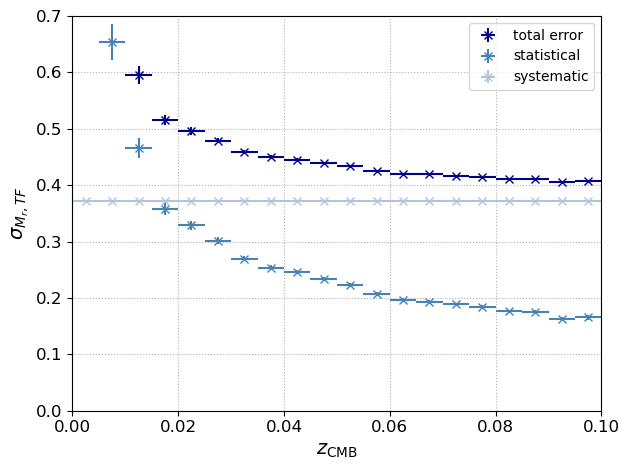

In [116]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

plt.figure(tight_layout=True)

# plt.plot(tf_data['Z_DESI_CMB'][sample1], tf_data['R_ABSMAG_SB26_TF_ERR'][sample1], '.', alpha=0.1)

# Total uncertainty
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='total error')

# Statistical uncertainty (just from velocity uncertainty)
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR_STAT'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='steelblue', label='statistical')

# Systematic uncertainty (from TF calibration)
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_ABSMAG_SB26_TF_ERR_SYS'][sample1], 
                                    zbins, 
                                    median=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='systematic')

plt.grid(ls=':')

plt.legend()

plt.xlim(0, 0.1)
plt.ylim(0, 0.7)

plt.tick_params(axis='both', which='major', labelsize=12)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=14)
plt.ylabel(r'$\sigma_{M_r, TF}$', fontsize=14);

## Compute distance modulus based on our TFR

In [117]:
sgatab['MU_TF'] = sgatab['R_MAG_SB26_CORR'] - sgatab['R_ABSMAG_SB26_TF']

sgatab['MU_TF_ERR'] = np.sqrt(sgatab['R_MAG_SB26_ERR_CORR']**2 + sgatab['R_ABSMAG_SB26_TF_ERR']**2)

## $\Delta M_r$ v. redshift

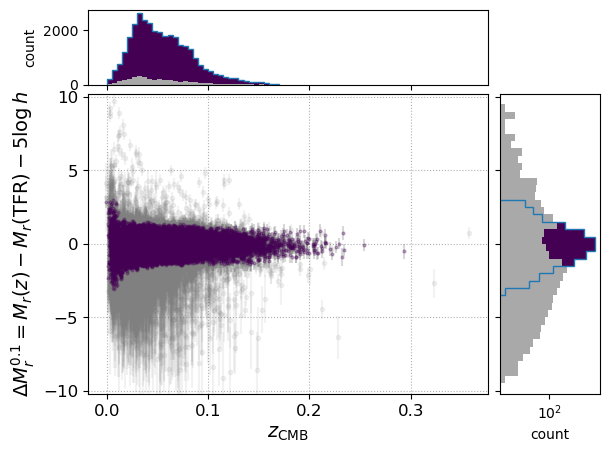

In [118]:
fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

sample = outlier_boolean# & morph_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

sample = ~outlier_boolean
ax.errorbar(sgatab['Z_DESI_CMB'][sample], 
             sgatab['R_ABSMAG_SB26'][sample] - sgatab['R_ABSMAG_SB26_TF'][sample], 
             xerr=sgatab['ZERR_DESI'][sample], 
             yerr=sgatab['MU_TF_ERR'][sample],
             fmt='.', 
             markersize=4, 
             alpha=0.3, 
             ecolor='gray')

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\Delta M_r^{0.1} = M_r(z) - M_r(\text{TFR}) - 5\log h$', fontsize=14)

ax.set_ylim((-10.2, 10.2))


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][~outlier_boolean],
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
sample1 = ~outlier_boolean
sample2 = outlier_boolean
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample2] - sgatab['R_ABSMAG_SB26_TF'][sample2], 
              bins=np.arange(-12.5, 10, 0.5), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['R_ABSMAG_SB26'][sample1] - sgatab['R_ABSMAG_SB26_TF'][sample1], 
              bins=np.arange(-12.5, 10, 0.5), 
              orientation='horizontal', 
              histtype='step', 
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

## $\eta$ v. redshift

In [119]:
sgatab['LOGDIST'] = 0.2*(sgatab['MU_ZCMB'] - sgatab['MU_TF'])
sgatab['LOGDIST_ERR'] = 0.2*np.sqrt(sgatab['MU_ZCMB_ERR']**2 + sgatab['MU_TF_ERR']**2)

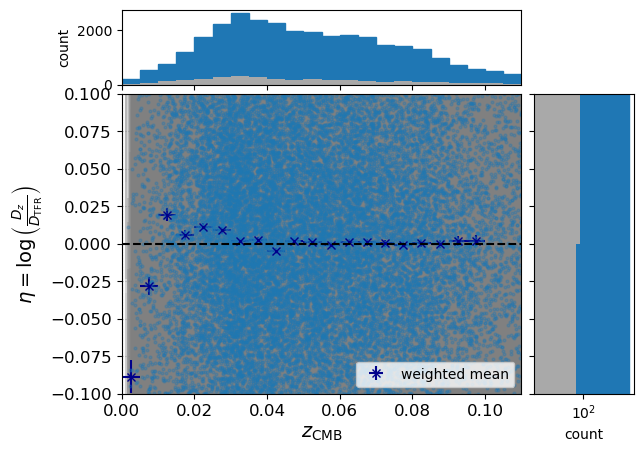

In [120]:
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1 = ~outlier_boolean
sample2 = outlier_boolean

fig = plt.figure()

gs = fig.add_gridspec(2, 2, width_ratios=(4,1), height_ratios=(1,4), left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.05, hspace=0.05)

ax = fig.add_subplot(gs[1,0])

ax.errorbar(sgatab['Z_DESI_CMB'][sample2], 
             sgatab['LOGDIST'][sample2], 
             xerr=sgatab['ZERR_DESI'][sample2], 
             yerr=sgatab['LOGDIST_ERR'][sample2],
             fmt='.', 
             color='gray',
             alpha=0.1, 
             ecolor='gray')

ax.errorbar(sgatab['Z_DESI_CMB'][sample1], 
             sgatab['LOGDIST'][sample1], 
             xerr=sgatab['ZERR_DESI'][sample1], 
             yerr=sgatab['LOGDIST_ERR'][sample1],
             fmt='.', 
             markersize=4, 
             alpha=0.3,
             color='tab:blue',
             ecolor='gray')

# Plot the weighted mean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='weighted mean')
'''
# Plot the median
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['R_LOGDIST'][sample1], 
                                    zbins, 
                                    median=True)
ax.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='lightsteelblue', label='median')
'''
# Line at eta = 0
ax.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)

ax.legend()

ax.grid(ls=':')

plt.tick_params(axis='both', which='major', labelsize=12)

ax.set_xlabel(r'$z_{\text{CMB}}$', fontsize=14)
ax.set_ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', fontsize=14)

# ax.set_ylim((-1.9, 1.9))
ax.set_xlim((0, 0.2))
# ax.set_ylim((-0.5, 0.5))
ax.set_ylim((-0.1, 0.1))
ax.set_xlim((0, 0.11))

ax.grid(ls=':')


ax_histx = fig.add_subplot(gs[0,0], sharex=ax)
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              color='tab:blue',
              bins=np.arange(0, 0.175, 0.005))
ax_histx.hist(sgatab['Z_DESI_CMB'][sample2], 
              bins=np.arange(0, 0.175, 0.005), 
              color='darkgray')
ax_histx.hist(sgatab['Z_DESI_CMB'][sample1], 
              bins=np.arange(0, 0.175, 0.005), 
              color='tab:blue', 
              histtype='step')

ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel('count')


ax_histy = fig.add_subplot(gs[1,1], sharey=ax)
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1),
              color='tab:blue',
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample2], 
              bins=np.arange(-2, 2, 0.1), 
              color='darkgray', 
              orientation='horizontal')
ax_histy.hist(sgatab['LOGDIST'][sample1], 
              bins=np.arange(-2, 2, 0.1), 
              orientation='horizontal', 
              histtype='step',
              color='tab:blue')

ax_histy.set_xscale('log')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel('count');

# plt.savefig('../../Figures/Y1/iron_logdist-v-z_jointTFR-varyV0-perpdwarfs_z0p1_Anthony2_weightsVmax-1_dVsys_20250717.png', 
#             dpi=150, 
#             facecolor='none', 
#             bbox_inches='tight');

/tmp/ipykernel_1286402/4204720653.py:26: RuntimeWarning: invalid value encountered in log10
  deltamarray = np.log10(dzarray/dharray)


(0.0, 0.105)

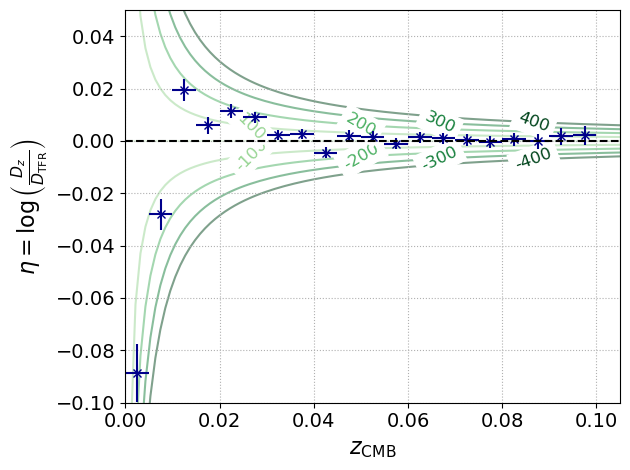

In [121]:
plt.figure(tight_layout=True)

# zbins = np.arange(0, 0.1025, 0.0025)
zbins = np.arange(0, 0.105, 0.005)
dz = 0.5*np.diff(zbins)
zc = 0.5*(zbins[1:] + zbins[:-1])

sample1=~outlier_boolean
N, y_avg, y_std = profile_histogram(sgatab['Z_DESI_CMB'][sample1], 
                                    sgatab['LOGDIST'][sample1], 
                                    zbins, 
                                    weights=sgatab['LOGDIST_ERR'][sample1]**-2, 
                                    weighted=True)
plt.errorbar(zc, y_avg, xerr=dz, yerr=y_std, fmt='x', color='darkblue', label='Main sample')



# PV lines (code taken from Cullen)
c = const.c.to('km/s')
velarray = np.arange(-400, 401, 100)
zarray = np.linspace(0.00005, 0.21, 200)

dzarray = cosmo.comoving_distance(zarray).value
dharray = cosmo.comoving_distance(np.outer(1.0/(1.0 + velarray/c.value), 
								  (1.0 + zarray)) - 1.0).value
deltamarray = np.log10(dzarray/dharray)

rotation = [20.0, 25.0, 30.0, 45.0, 0.0, -45.0, -30.0, -25.0, -20.0]
labels = ["-400", "-300", "-200", "-100", "0", "100", "200", "300", "400"]
xcoord = np.array([26000.0, 20000.0, 15000.0, 8000.0, -1000.0, 8000.0, 15000.0, 20000.0, 26000.0])
coord = np.searchsorted(zarray, xcoord/c.value)
ycoord = np.array([deltamarray[i,j] for i, j in enumerate(coord)])

colors = 0.8*np.fabs(velarray)/np.amax(np.fabs(velarray)) + 0.2

for v in range(len(velarray)):
    col = plt.cm.Greens(colors[v])

    plt.plot(zarray, deltamarray[v,:], 
             color=col, 
             linestyle='-', 
             alpha=0.5, 
             zorder=0)

    if (v != 4):
        plt.text(xcoord[v]/c.value, ycoord[v], 
                 labels[v], 
                 color=col, 
                 fontsize=12, 
                 rotation=rotation[v], 
                 ha="center", 
                 va="center", 
                 bbox=dict(boxstyle="square", ec="w", fc="w"), 
                 zorder=1)

# Line at eta = 0
plt.hlines(0, 0, 0.2, linestyles='dashed', colors='k', zorder=5)
#-------------------------------------------------------------------------------

plt.grid(ls=':')

# plt.vlines([0.03, 0.1], -0.05, 0.05, colors='gray', linestyles='dashed')

plt.tick_params(axis='both', which='major', labelsize=14)

plt.xlabel(r'$z_{\text{CMB}}$', fontsize=16)
plt.ylabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
           fontsize=16)

plt.ylim((-0.1, 0.05))
# plt.ylim((-0.12, 0.1))
# plt.ylim((-0.2, 0.2))
plt.xlim((0, 0.105))
# plt.xlim((0, 0.2))

# plt.legend(loc='lower right');

# plt.savefig('/pscratch/sd/s/sgmoore1/TF/figures/TFR_Y3_v2_eta_z.png',facecolor='none')

In [122]:
# Create a single column to denote which objects should be used for cosmological analysis
sgatab['OUTLIER'] = outlier_boolean
sgatab['MAIN'] = ~sgatab['OUTLIER'] & sgatab['GOOD_MORPH']

In [74]:
hdr = fits.Header()

hdr['DESI_DR'] = 'DR1'
hdr['V_RADIUS'] = '0.4 R26'
hdr['M'] = slope
hdr['M_ERR'] = slope_err
# hdr['0PT'] = ZP
# hdr['0PT_ERR'] = ZP_err
hdr['logV0'] = logV0
hdr['SIG'] = np.median(tfr_mcmc_samples[-1])
hdr['SIG_ERR'] = np.sqrt(cov_tfr[-1,-1])
hdr['H0'] = H0
hdr['EL_STD'] = sigma
hdr['EL_TYPE'] = 'binned'


# hdr['EL_MU_X'] = ellipse_mean[0]
# hdr['EL_MU_Y'] = ellipse_mean[1]

# # Ellipse covariance matrix
# hdr['EL_COV00'] = ellipse_cov[0, 0]
# hdr['EL_COV01'] = ellipse_cov[0, 1]
# hdr['EL_COV10'] = ellipse_cov[1, 0]
# hdr['EL_COV11'] = ellipse_cov[1, 1]


empty_primary = fits.PrimaryHDU(header=hdr)

In [75]:
table_hdu = fits.BinTableHDU(data=sgatab)

hdul = fits.HDUList([empty_primary, table_hdu])

# Write results to file
hdul.writeto('../eta_cats/SGA_jura_jointTFR_v3.fits', 
             overwrite=True)

In [76]:
hdul.writeto('/global/cfs/cdirs/desi/science/td/pv/tfgalaxies/Y3/DESI-DR2_TF_pv_cat_v3.fits', 
             overwrite=True)